In [1]:
import os
import sys
import dill
import pprint
from pathlib import Path
import pathos
sys.path.append('/Users/leonardo.tessarolo/git/bayesian_bss/')

import numpy as np
import functools
import pandas as pd
import scipy.stats as st
from numpyro.diagnostics import gelman_rubin

from matplotlib import pyplot as plt

from src import ExponentialPrior, LogisticSource, TriangularSource, StandardLogisticSource, StudentTSource, ExperimentExecutor, ExperimentParser
np.random.seed(100)

In [2]:
# Whether or not to create config
EXECUTE=True

# Whether or not to create folder structure
CREATE_FOLDER_STRUCTURE=False

# Experiment name
EXPERIMENT_NAME='CBA_SBRT_complete_analysis'

# Folder which will contain output directory tree
OUTPUT_DIR='./output'
base_output_path=Path(OUTPUT_DIR)

# Create experiment directory
experiment_dir = base_output_path / EXPERIMENT_NAME

# 1. Definir classes

## MMSEMetropolisHastingsEstimator

In [3]:
# class MMSEMetropolisHastingsEstimator:
    
#     def __init__(
#         self,
#         n_samples: int,
#         source_pdf_fn,
#         prior_pdf_fn,
#         exploration_var,
#         parallel_chains,
#         max_it,
#         R_hat_thresh=1.01,
#         R_hat_evaluation_step=100,
#         R_hat_persistance=5,
#         R_hat_minimum_burn_in=1000
#     ):
#         self.n_samples=n_samples
#         self.log_posterior_fn=PosteriorUtilities.get_log_posterior_fn(
#             source_pdf_fn=source_pdf_fn,
#             prior_pdf_fn=prior_pdf_fn
#         )
#         self.Q=self.__get_Q(
#             exploration_var=exploration_var
#         )
#         self.R_hat_thresh=R_hat_thresh
#         self.parallel_chains=parallel_chains
#         self.max_it=max_it
#         self.n_samples_per_chain = n_samples//parallel_chains
#         self.R_hat_minimum_evaluation=R_hat_minimum_burn_in + self.n_samples_per_chain
#         self.R_hat_persistance=R_hat_persistance
#         self.R_hat_evaluation_step=R_hat_evaluation_step
    

#     def __get_Q(
#         self,
#         exploration_var
#     ):
#         """
#             This method obtains the Q function for metropolis-hastings algorithm. The Q function takes in a current value
#             of the estimated parameters and proposes a new one.
#         """
#         def __proposal_fn(
#             exploration_var,
#             B
#         ):
#             # Calculate shift in parameter
#             shift = np.random.normal(
#                 loc=0,
#                 scale=np.sqrt(exploration_var),
#                 size=B.shape
#             )
        
#             # Sum shift to obtain new parameter value
#             new_B = np.add(
#                 B, shift
#             )
        
#             return new_B

#         return lambda B: __proposal_fn(
#             exploration_var=exploration_var,
#             B=B
#         )
    
    
#     def fit(
#         self,
#         x,
#         initial_condition
#     ):
        
#         def __get_samples(
#             log_posterior_fn,
#             x,
#             n_samples: int,
#             initial_value,
#             chain
#         ):
            
#             # Number of observations and sources
#             NOBS=x.shape[-1]
#             NSOURCES=x.shape[0]

#             # Inicialização aleatória de B
#             B = initial_value
#             logs = pd.DataFrame()

#             max_posterior = -np.inf
#             n=1
#             MH_samples = []
#             last_B = initial_value
#             new_B = None
#             logs = pd.DataFrame()
#             for i in range(n_samples):
                
#                 # Get new B
#                 new_B = self.Q(last_B)
                
#                 # Get proposal alpha
#                 alpha_proposal = log_posterior_fn(x, new_B) - log_posterior_fn(x, last_B)
                
#                 # Check whether it is greater than 0 and anti-transform alpha to yield a probability
#                 alpha = 1 if alpha_proposal > 0 else np.exp(alpha_proposal)
            
#                 # Get random uniform sample and check whether it is smaller than alpha. This will
#                 # say if new sample is accepted
#                 choice_sample = np.random.uniform(0,1)
#                 save_new_sample = choice_sample < alpha
                
#                 # Save new sample or current one
#                 if save_new_sample:
#                     MH_samples.append(new_B)
#                     last_B=new_B
#                 else:
#                     MH_samples.append(last_B)

#                 # Save to log
#                 logs = pd.concat(
#                     [
#                         logs,
#                         pd.DataFrame(
#                             index=[i],
#                             data={
#                                 'inside_iteration': [i+1],
#                                 'B_sample': [last_B],
#                                 'alpha': [alpha],
#                                 'save_new_sample': [save_new_sample],
#                                 'log_posterior': [log_posterior_fn(x, last_B)/NOBS]
#                             }
#                         )
#                     ]
#                 )
            
#             logs['chain'] = chain
            
#             return np.array(MH_samples), logs
        
#         def __get_R_hats(
#             samples,
#             iteration
#         ):
#             iteration_samples = samples[0].shape[0]
#             r_hats = {'iteration': [iteration]}
#             for i,j in np.ndindex((samples[0].shape[-2], samples[0].shape[-1])):
#                 # Get samples across chains for coefficient ij
#                 bij_samples = np.array([
#                     samples[c][:,i,j] for c in range(self.parallel_chains)
#                 ])

#                 # Evaluate r-hat
#                 r_hats['b_{}{}'.format(i+1, j+1)] = [gelman_rubin(x=bij_samples)]

#             return pd.DataFrame(
#                 index=[0],
#                 data=r_hats
#             )
        

#         def __get_next_iteration(
#             R_hats,
#             it
#         ):

#             # Evaluate persistance
#             if R_hats.shape[0] < self.R_hat_persistance:
#                 stop=False
#             # If at least R_hat_persistance evaluations held:
#             else:
#                 if it < self.max_it:
#                     # Evaluate if all R_hats converged for R_hat_persistance evaluations
#                     if np.all(
#                         R_hats.drop(
#                             columns=['iteration']
#                         ).values[-self.R_hat_persistance:,:] < self.R_hat_thresh
#                     ):
#                         stop=True
#                         self.converged=True
#                     else:
#                         stop=False
#                 # Evaluate maximum iterations
#                 else:
#                     stop=True
#                     self.converged=False

#             # Increment iteration
#             if not stop:
#                 it += self.R_hat_evaluation_step

#             return stop, it
            


#         def __parse_MCMC_results(
#             chains_samples,
#             R_hats,
#             logs 
#         ):
            
#             # Merge samples from different chains into one vector
#             merged_samples = np.concatenate(
#                 [
#                     s[-self.n_samples_per_chain:,:,:] for s in chains_samples
#                 ],
#                 axis=0
#             )

#             # Get index for which maximum posterior was found
#             max_posterior_idx = logs[
#                 logs.iteration > logs.iteration.max() - self.n_samples_per_chain
#             ].log_posterior.idxmax()

#             # Get max posterior sample and index
#             max_posterior = logs.loc[max_posterior_idx]['log_posterior']
#             max_posterior_B = logs.loc[max_posterior_idx]['B_sample']

#             # Get Monte Carlo MMSE estimate
#             B_est_mmse = np.mean(
#                 merged_samples,
#                 axis=0
#             )

#             # Average alpha in stationarity
#             average_alpha = logs[
#                 logs.iteration > logs.iteration.max() - self.n_samples_per_chain
#             ].alpha.mean()

#             # Store parsed results
#             parsed_results = {
#                 'samples': merged_samples,
#                 'R_hats': R_hats,
#                 'logs': logs,
#                 'B_est': B_est_mmse,
#                 'max_posterior': max_posterior,
#                 'max_posterior_B': max_posterior_B,
#                 'average_alpha': average_alpha
#             }

#             # Save parsed results
#             self.mcmc_results = parsed_results


#         # Run initial period (minimum R-hat evaluation samples)
#         results_minimum_eval = [
#             __get_samples(
#                 log_posterior_fn=self.log_posterior_fn,
#                 x=x,
#                 n_samples=self.R_hat_minimum_evaluation,
#                 initial_value=B0,
#                 chain=c
#             ) for c, B0 in zip(
#                 range(self.parallel_chains), 
#                 initial_condition
#             )
#         ]

#         # Append samples
#         samples = np.array([
#             tup[0] for tup in results_minimum_eval
#         ])

#         # Append logs
#         logs = pd.concat(
#             [
#                 tup[-1] for tup in results_minimum_eval
#             ],
#             axis=0
#         )

#         # Get R-hats
#         R_hats = __get_R_hats(
#             samples=np.array([
#                 samples_chain[-self.n_samples_per_chain:,:,:] for samples_chain in samples
#             ]),
#             iteration=self.R_hat_minimum_evaluation
#         )

#         # Run loop
#         it = self.R_hat_minimum_evaluation + self.R_hat_evaluation_step
#         stopping_condition=False
#         while not stopping_condition:
#             # Run incremental period for evaluating R-hat
#             results_incremental_eval = [
#                 __get_samples(
#                     log_posterior_fn=self.log_posterior_fn,
#                     x=x,
#                     n_samples=self.R_hat_evaluation_step,
#                     initial_value=samples[c][-1,:,:],
#                     chain=c
#                 ) for c in range(self.parallel_chains)
#             ]

#             # Append samples
#             samples_incremental = np.array([
#                 tup[0] for tup in results_incremental_eval
#             ])
#             samples = np.array([
#                 np.concatenate(
#                     [
#                         s,
#                         s_inc
#                     ],
#                     axis=0
#                 ) for s, s_inc in zip(
#                     samples, samples_incremental
#                 )
#             ])

#             # Append logs
#             logs_incremental = pd.concat(
#                 [
#                     tup[-1] for tup in results_incremental_eval
#                 ],
#                 axis=0
#             )
#             logs = pd.concat(
#                 [
#                     logs,
#                     logs_incremental
#                 ],
#                 axis=0
#             ).reset_index(
#                 drop=True
#             )

#             # Get R-hats
#             R_hats = pd.concat(
#                 [
#                     R_hats,
#                     __get_R_hats(
#                         samples=np.array([
#                             samples_chain[-self.n_samples_per_chain:,:,:] for samples_chain in samples
#                         ]),
#                         iteration=it
#                     )
#                 ]               
#             ).reset_index(
#                 drop=True
#             )

#             # Evaluate next iteration
#             stopping_condition, it = __get_next_iteration(
#                 R_hats=R_hats,
#                 it=it
#             )

#         # Get iterations per chain
#         logs['iteration'] = logs.groupby(
#             by='chain'
#         ).cumcount() + 1
        

#         # Parse results
#         __parse_MCMC_results(
#             chains_samples=samples,
#             R_hats=R_hats,
#             logs=logs
#         )

#         self.samples=samples
#         self.R_hats=R_hats
#         self.logs=logs

#         return samples, R_hats, logs

## BayesianEstimators

In [4]:
# class BayesianEstimators:

#     @staticmethod
#     def generate_configs(
#         source_pdf,
#         source_pdf_derivative,
#         prior_pdf,
#         prior_pdf_derivative,
#         normalize_posterior,
#         n_samples_mcmc,
#         exploration_var_mcmc,
#         parallel_chains_mcmc,
#         max_it_mcmc,
#         R_hat_thresh_mcmc,
#         R_hat_evaluation_step_mcmc,
#         R_hat_persistance_mcmc,
#         R_hat_minimum_burn_in_mcmc,
#         learning_rate_grad_asc,
#         stopping_thresh_grad_asc,
#         max_it_grad_asc,
#         stopping_criterion_persistance_its_grad_asc,
#         is_natural_gradient_grad_asc=False
#     ):

#         # Create MCMC config
#         mcmc_configs = {
#             'n_samples': n_samples_mcmc,
#             'source_pdf_fn': source_pdf,
#             'prior_pdf_fn': prior_pdf,
#             'exploration_var': exploration_var_mcmc,
#             'parallel_chains': parallel_chains_mcmc,
#             'max_it': max_it_mcmc,
#             'R_hat_thresh': R_hat_thresh_mcmc,
#             'R_hat_evaluation_step': R_hat_evaluation_step_mcmc,
#             'R_hat_persistance': R_hat_persistance_mcmc,
#             'R_hat_minimum_burn_in': R_hat_minimum_burn_in_mcmc
#         }

#         # Create Gradient Ascent config
#         grad_asc_configs = {
#             'learning_rate': learning_rate_grad_asc,
#             'thresh': stopping_thresh_grad_asc,
#             'max_it': max_it_grad_asc,
#             'stopping_criterion_persistance_its': stopping_criterion_persistance_its_grad_asc,
#             'source_pdf': source_pdf,
#             'source_pdf_derivative': source_pdf_derivative,
#             'prior_pdf': prior_pdf,
#             'prior_pdf_derivative': prior_pdf_derivative,
#             'normalize_posterior': normalize_posterior,
#             'is_natural_gradient': is_natural_gradient_grad_asc
#         }

#         return mcmc_configs, grad_asc_configs
        
        
#     @staticmethod
#     def run(
#         s,
#         x,
#         mmse_configs,
#         map_configs,
#         initial_conditions
#     ):
        
#         # Initialize MH estimator
#         mmse_estimator = MMSEMetropolisHastingsEstimator(
#             n_samples=mmse_configs['n_samples'],
#             source_pdf_fn=mmse_configs['source_pdf_fn'],
#             prior_pdf_fn=mmse_configs['prior_pdf_fn'],
#             exploration_var=mmse_configs['exploration_var'],
#             parallel_chains=mmse_configs['parallel_chains'],
#             max_it=mmse_configs['max_it'],
#             R_hat_thresh=mmse_configs['R_hat_thresh'],
#             R_hat_evaluation_step=mmse_configs['R_hat_evaluation_step'],
#             R_hat_persistance=mmse_configs['R_hat_persistance'],
#             R_hat_minimum_burn_in=mmse_configs['R_hat_minimum_burn_in']
#         )
#         if mmse_configs['run_mcmc']:
#             # Execute MCMC estimation
#             mmse_estimator.fit(
#                 x=x,
#                 initial_condition=initial_conditions['mmse']
#             )
    
#         # Initialize MAP estimator
#         map_estimator = MAPGradientAscentEstimator(
#             learning_rate=map_configs['learning_rate'],
#             thresh=map_configs['thresh'],
#             max_it=map_configs['max_it'],
#             stopping_criterion_persistance_its=map_configs['stopping_criterion_persistance_its'],
#             source_pdf=map_configs['source_pdf'],
#             source_pdf_derivative=map_configs['source_pdf_derivative'],
#             prior_pdf=map_configs['prior_pdf'],
#             prior_pdf_derivative=map_configs['prior_pdf_derivative'],
#             normalize_posterior=map_configs['normalize_posterior'],
#             is_natural_gradient=map_configs['is_natural_gradient']
#         )
#         if map_configs['run_grad_asc']:
#             # Run optimization
#             map_estimator.fit(
#                 s=s,
#                 x=x,
#                 initial_condition=initial_conditions['map']
#             )

#         return mmse_estimator, map_estimator

## ExperimentExecutor

In [5]:
# class ExperimentExecutor:

#     def __init__(
#         self,
#         cfg,
#         initialize=True
#     ):
#         if initialize:
#             # Save cfg as attribute
#             self.cfg=cfg

#             # Save test cases as attribute
#             self.test_cases = list(self.cfg['sim']['test_cases'].keys())
            
#             # Get source and mixture signals for all realizations
#             self.__initialize_signals()

#             # Get source model and prior distributions
#             self.__get_test_case_distributions()

#             # Get execution functions for test cases
#             self.__get_exec_fns()

#             # Run initial mode seeking
#             self.__run_initial_mode_seeking()

#             # Get initial starting points for Gradient Ascent and MCMC
#             self.__get_initial_conditions()

#             # Save cfg and signals
#             self.__save_initializations()

#         else:
#             self.cfg=cfg

#             self.__read_signals()

    
#     def __initialize_signals(
#         self
#     ):
#         # Parse config object
#         A = self.cfg['general']['A']
#         n_realizations = self.cfg['general']['n_realizations']
#         n_sources = self.cfg['general']['n_sources']
#         n_obs = self.cfg['general']['n_obs']

#         # Initialize random seeds
#         seeds = [x for x in range(n_realizations)]
        
#         # Initialize dict to keep signals
#         signals = {}
        
#         # Iterate over realizations and generate signals
#         for r in range(n_realizations):
#             realization = {}
#             # Generate sources for each specified configuration
#             for s_name, s_obj in self.cfg['sim']['sources'].items():
#                 # Get source realization
#                 s = s_obj.get_realization(
#                     nsources=n_sources,
#                     nobs=n_obs,
#                     seed=seeds[r]
#                 )
#                 # Get mixtures
#                 x = A@s
#                 # Save signals
#                 realization[s_name] = {
#                     's': s,
#                     'x': x
#                 }
#                 signals[str(r)] = realization

#         self.signals=signals
        
    
#     def __get_test_case_distributions(
#         self
#     ):
#         # Iterate over test cases and save distributions
#         for test_case, test_case_cfgs in self.cfg['sim']['test_cases'].items():
#             # Source and prior
#             source = self.cfg['sim']['source_model']
#             prior = self.cfg['sim']['priors'][test_case_cfgs['prior']]
            
#             # Get source model pdfs
#             source_model_pdf = source.get()
#             source_model_pdf_derivative = source.get_derivative()

#             # Get prior pdfs
#             prior_pdf = prior.get()
#             prior_pdf_derivative = prior.get_derivative()

#             ########################################
#             # Configs for initialization execution #
#             ########################################

#             # Configurations for MCMC sampling and Gradient Ascent optimization
#             initialization_mcmc_configs, initialization_grad_asc_configs =  BayesianEstimators.generate_configs(
#                 source_pdf=source_model_pdf,
#                 source_pdf_derivative=source_model_pdf_derivative,
#                 prior_pdf=prior_pdf,
#                 prior_pdf_derivative=prior_pdf_derivative,
#                 normalize_posterior=self.cfg['general']['normalize_posterior'],
#                 n_samples_mcmc=self.cfg['mcmc']['n_samples'],
#                 exploration_var_mcmc=self.cfg['mcmc']['exploration_var'],
#                 parallel_chains_mcmc=self.cfg['mcmc']['parallel_chains'],
#                 max_it_mcmc=self.cfg['mcmc']['max_it'],
#                 R_hat_thresh_mcmc=self.cfg['mcmc']['R_hat_thresh'],
#                 R_hat_evaluation_step_mcmc=self.cfg['mcmc']['R_hat_evaluation_step'],
#                 R_hat_persistance_mcmc=self.cfg['mcmc']['R_hat_persistance'],
#                 R_hat_minimum_burn_in_mcmc=self.cfg['mcmc']['R_hat_minimum_burn_in'],
#                 learning_rate_grad_asc=self.cfg['initial_mode_seeking']['learning_rate'],
#                 stopping_thresh_grad_asc=self.cfg['initial_mode_seeking']['stopping_thresh'],
#                 max_it_grad_asc=self.cfg['initial_mode_seeking']['max_it'],
#                 stopping_criterion_persistance_its_grad_asc=self.cfg['initial_mode_seeking']['stopping_criterion_persistance_its']
#             )

#             # Set configuration in estimators to run both
#             initialization_mcmc_configs['run_mcmc'] = False
#             initialization_grad_asc_configs['run_grad_asc'] = True

#             # Save MAP and MCMC configs
#             self.cfg['sim']['test_cases'][test_case]['initialization_mcmc_configs']=initialization_mcmc_configs
#             self.cfg['sim']['test_cases'][test_case]['initialization_grad_asc_configs']=initialization_grad_asc_configs

#             ##################################
#             # Configs for standard execution #
#             ##################################

#             # Configurations for MCMC sampling and Gradient Ascent optimization
#             mcmc_configs, grad_asc_configs =  BayesianEstimators.generate_configs(
#                 source_pdf=source_model_pdf,
#                 source_pdf_derivative=source_model_pdf_derivative,
#                 prior_pdf=prior_pdf,
#                 prior_pdf_derivative=prior_pdf_derivative,
#                 normalize_posterior=self.cfg['general']['normalize_posterior'],
#                 n_samples_mcmc=self.cfg['mcmc']['n_samples'],
#                 exploration_var_mcmc=self.cfg['mcmc']['exploration_var'],
#                 parallel_chains_mcmc=self.cfg['mcmc']['parallel_chains'],
#                 max_it_mcmc=self.cfg['mcmc']['max_it'],
#                 R_hat_thresh_mcmc=self.cfg['mcmc']['R_hat_thresh'],
#                 R_hat_evaluation_step_mcmc=self.cfg['mcmc']['R_hat_evaluation_step'],
#                 R_hat_persistance_mcmc=self.cfg['mcmc']['R_hat_persistance'],
#                 R_hat_minimum_burn_in_mcmc=self.cfg['mcmc']['R_hat_minimum_burn_in'],
#                 learning_rate_grad_asc=self.cfg['map']['learning_rate'],
#                 stopping_thresh_grad_asc=self.cfg['map']['stopping_thresh'],
#                 max_it_grad_asc=self.cfg['map']['max_it'],
#                 stopping_criterion_persistance_its_grad_asc=self.cfg['map']['stopping_criterion_persistance_its']
#             )

#             # Set configuration in estimators to run both
#             mcmc_configs['run_mcmc'] = True
#             grad_asc_configs['run_grad_asc'] = True

#             # Save MAP and MCMC configs
#             self.cfg['sim']['test_cases'][test_case]['mcmc_configs']=mcmc_configs
#             self.cfg['sim']['test_cases'][test_case]['grad_asc_configs']=grad_asc_configs

#     def __get_exec_fns(
#         self
#     ):
#         def __run_estimators(
#             mcmc_configs,
#             grad_asc_configs,
#             initial_conditions,
#             s,
#             x
#         ):
#             """
#                 Runs estimators for one realization
#             """
#             # Run estimators
#             mmse_estimator, map_estimator = BayesianEstimators.run(
#                 s=s,
#                 x=x,
#                 mmse_configs=mcmc_configs,
#                 map_configs=grad_asc_configs,
#                 initial_conditions=initial_conditions
#             )

#             return mmse_estimator, map_estimator

#         def __run_contour(
#             u_lims,
#             v_lims,
#             central_point,
#             contour_grid_points,
#             source_model_pdf,
#             prior_pdf,
#             A,
#             n_obs,
#             n_workers,
#             x
#         ):
#             """
#                 Runs posteriori grid for one realization
#             """
#             # Initialize object used to obtain contour lines
#             c_lines = PosteriorContourLines(
#                 u_lims=u_lims,
#                 v_lims=v_lims,
#                 n_points=contour_grid_points,
#                 central_point=central_point,
#                 source_pdf_fn=source_model_pdf,
#                 prior_pdf_fn=prior_pdf,
#             )
            
#             # Evaluate posterior in neighborhood of true point
#             c_lines.get_posteriori_neighborhood(
#                 A=A,
#                 x=x,
#                 N=n_obs,
#                 njobs=n_workers
#             )
            
#             # Maximum a posteriori point
#             c_lines.get_max_point()

#             return c_lines

        
#         # Iterate over test cases and obtain functions to be executed for each realization
#         for test_case, test_case_cfgs in self.cfg['sim']['test_cases'].items():
            
#             # Bayesian estimators execution function - initial mode seeking
#             initialization_bayesian_estimators_fn = functools.partial(
#                 __run_estimators,
#                 test_case_cfgs['initialization_mcmc_configs'],
#                 test_case_cfgs['initialization_grad_asc_configs']
#             )

#             # Bayesian estimators execution function - regular executions
#             bayesian_estimators_fn = functools.partial(
#                 __run_estimators,
#                 test_case_cfgs['mcmc_configs'],
#                 test_case_cfgs['grad_asc_configs']
#             )

#             # Posteriori grid execution function
#             posteriori_grid_fn = functools.partial(
#                 __run_contour,
#                 self.cfg['contour']['u_lims'],
#                 self.cfg['contour']['v_lims'],
#                 self.cfg['contour']['central_point'],
#                 self.cfg['contour']['contour_grid_points'],
#                 test_case_cfgs['grad_asc_configs']['source_pdf'],
#                 test_case_cfgs['grad_asc_configs']['prior_pdf'],
#                 self.cfg['general']['A'],
#                 self.cfg['general']['n_obs'],
#                 self.cfg['general']['n_workers'],
#             )

#             # Save functions
#             self.cfg['sim']['test_cases'][test_case]['initialization_bayesian_estimators_fn']=initialization_bayesian_estimators_fn
#             self.cfg['sim']['test_cases'][test_case]['bayesian_estimators_fn']=bayesian_estimators_fn
#             self.cfg['sim']['test_cases'][test_case]['posteriori_grid_fn']=posteriori_grid_fn


#     def __run_initial_mode_seeking(
#         self
#     ):
#         def __run_realization(
#             cfg,
#             realization_info,
#         ):
#             """
#                 Runs initial mode seeking for one realization
#             """
#             # Parse realization info
#             realization_name = realization_info[0]
#             realization_cfgs = realization_info[-1]
            
#             # Iterate over test cases and execute experiment
#             realization_results = {}
#             for test_case, test_case_cfgs in self.cfg['sim']['test_cases'].items():
#                 # Source for test case
#                 test_case_source = test_case_cfgs['source']

#                 # Obtain sources and mixtures
#                 s = realization_cfgs[test_case_source]['s']
#                 x = realization_cfgs[test_case_source]['x']
                
#                 # Retrieve function for executing bayesian estimators 
#                 bayesian_estimators_fn = test_case_cfgs['initialization_bayesian_estimators_fn']

#                 # Run bayesian estimators
#                 _ , map_estimator = bayesian_estimators_fn(
#                     s=s,
#                     x=x,
#                     initial_conditions={
#                         'map': [self.cfg['general']['B']]
#                     }
#                 )
                
#                 # Updates realization cfgs
#                 realization_results[test_case] = {
#                     's': s,
#                     'x': x,
#                     'map_estimator': map_estimator
#                 }
            
#             # Saves to realization_cfgs
#             realization_cfgs['results'] = realization_results

#             # Save results
#             realization_dir = cfg['general']['experiment_dir']  / 'initial_mode_seeking' / realization_name
#             with (realization_dir/'results_raw.pkl').open('wb') as f:
#                 dill.dump(realization_cfgs, f)

#             return realization_results
        

#         def __parse_initial_mode_seeking_results(
#             results
#         ):
#             # Raw results
#             parsed_results = {
#                 'raw_results': results
#             }

#             # Estimated mode for each test case
#             estimated_modes = {
#                 test_case: np.median(
#                     np.array([
#                         res[test_case]['map_estimator'].B_est for res in results
#                     ]),
#                     axis=0
#                 ) for test_case in self.test_cases
#             }

#             # Save to parsed results
#             parsed_results['estimated_modes']=estimated_modes

#             # Save modes per test case
#             for test_case, mode in estimated_modes.items():
#                 self.cfg['sim']['test_cases'][test_case]['estimated_mode']=mode
                

#             return parsed_results
    


#         # Create execution functions for each realization
#         realization_fn = functools.partial(
#             __run_realization,
#             self.cfg
#         )
        
#         # Run experiment for each realization
#         iterable = list(self.__get_iterable())[:self.cfg['initial_mode_seeking']['n_realizations']]
#         if (self.cfg['general']['n_workers'] > 1) and (self.cfg['initial_mode_seeking']['n_realizations'] > 1):
#             with pathos.pools.ProcessPool(self.cfg['general']['n_workers']) as p:
#                 results = p.map(
#                     realization_fn, 
#                     iterable
#                 )
#         else:
#             results = [
#                 realization_fn(elem) for elem in iterable
#             ]

#         # Debug
#         # iterable = list(self.__get_iterable())[:self.cfg['initial_mode_seeking']['n_realizations']]
#         # results = [
#         #     realization_fn(elem) for elem in iterable
#         # ]

#         # Save as attribute
#         self.initial_mode_seeking_results = __parse_initial_mode_seeking_results(
#             results=results
#         )


#     def __get_initial_conditions(
#         self
#     ):
#         # Iterate test cases
#         for test_case in self.test_cases:
#             # Estimated mode
#             B_est = self.cfg['sim']['test_cases'][test_case]['estimated_mode']

#             # MAP starting point is estimated mode
#             map_initial_condition = [B_est]

#             # MMSE starting points follow starting distribution
#             mmse_initial_condition = [
#                 B_est + self.cfg['mcmc']['starting_distribution']() for _ in range(self.cfg['mcmc']['parallel_chains'])
#             ]

#             # Save initial conditions
#             self.cfg['sim']['test_cases'][test_case]['initial_conditions'] = {
#                 'map': map_initial_condition,
#                 'mmse': mmse_initial_condition
#             }

        

#     def __save_initializations(
#         self
#     ):
#         # Get experiment_dir
#         experiment_dir = self.cfg['general']['experiment_dir']
        
#         # Iterate over realizations and save signals
#         for r, res in self.signals.items():
#             # Get dir for saving realization results
#             realization_dir = experiment_dir / r

#             # Save results
#             with (realization_dir/'signals.pkl').open('wb') as f:
#                 dill.dump(res, f)

#         # Save updated config file
#         with (experiment_dir/'execution_config.pkl').open('wb') as f:
#                 dill.dump(self.cfg, f)


#     def __read_signals(
#         self
#     ):
        
#         # Get realization iterable
#         realizations = range(self.cfg['general']['n_realizations'])

#         # Get experiment dir
#         experiment_dir = self.cfg['general']['experiment_dir']

#         # Read signals
#         signals = {}
#         for r in realizations:
#             # Get dir for reading realization results
#             realization_dir = experiment_dir / str(r)

#             # Read signals
#             with (realization_dir/'signals.pkl').open('rb') as f:
#                 signals[str(r)] = dill.load(f)
            
#         self.signals=signals

#     def __get_iterable(
#             self
#     ):
#         # Get realization iterable
#         realizations = range(self.cfg['general']['n_realizations'])

#          # Get experiment dir
#         experiment_dir = self.cfg['general']['experiment_dir']

#         # Iterate and identify finished realizations
#         finished_realizations = []
#         for r in realizations:
            
#             # Get dir for reading realization results
#             realization_dir = experiment_dir / str(r)

#             # Read success flag
#             with (realization_dir/'success_flag.pkl').open('rb') as f:
#                 success_flag = dill.load(f)

#             if success_flag=='SUCCESS':
#                 finished_realizations.append(str(r))
        
        
#         # Get realizations to run
#         unfinished_realizations_signals = {
#             k:v for k, v in self.signals.items() if k not in finished_realizations
#         }

#         # Print status
#         print('#'*100)
#         print('Total realizations: {}'.format(self.cfg['general']['n_realizations']))
#         print('Finished realizations: {}'.format(len(finished_realizations)))
#         print('Unfinished realizations: {}'.format(len(unfinished_realizations_signals.keys())))
#         print('#'*100)

#         return unfinished_realizations_signals.items()
    

#     def run(
#         self
#     ):

#         def __run_realization(
#             cfg,
#             realization_info,
#         ):
#             """
#                 Runs experiment for one realization
#             """
#             # Parse realization info
#             realization_name = realization_info[0]
#             realization_cfgs = realization_info[-1]
            
#             # Iterate over test cases and execute experiment
#             realization_results = {}
#             for test_case, test_case_cfgs in self.cfg['sim']['test_cases'].items():
#                 # Source for test case
#                 test_case_source = test_case_cfgs['source']

#                 # Obtain sources and mixtures
#                 s = realization_cfgs[test_case_source]['s']
#                 x = realization_cfgs[test_case_source]['x']
                
#                 # Retrieve function for executing bayesian estimators 
#                 bayesian_estimators_fn = test_case_cfgs['bayesian_estimators_fn']

#                 # Run bayesian estimators
#                 mmse_estimator, map_estimator = bayesian_estimators_fn(
#                     s=s,
#                     x=x,
#                     initial_conditions=test_case_cfgs['initial_conditions']
#                 )
                
#                 # Retrieve function for executing posteriori grid calculation
#                 posteriori_grid_fn = test_case_cfgs['posteriori_grid_fn']
                
#                 # Run posteriori grid calculation
#                 posteriori_grid = posteriori_grid_fn(x=x)
                
#                 # Updates realization cfgs
#                 realization_results[test_case] = {
#                     's': s,
#                     'x': x,
#                     'mmse_estimator': mmse_estimator,
#                     'map_estimator': map_estimator,
#                     'posteriori_grid': posteriori_grid
#                 }

#             # Saves to realization_cfgs
#             realization_cfgs['results'] = realization_results

#             # Save results
#             realization_dir = cfg['general']['experiment_dir']  / realization_name
#             with (realization_dir/'results_raw.pkl').open('wb') as f:
#                 dill.dump(realization_cfgs, f)

#             with (realization_dir/'success_flag.pkl').open('wb') as f:
#                 dill.dump('SUCCESS', f)


#         # Create execution functions for each realization
#         realization_fn = functools.partial(
#             __run_realization,
#             self.cfg
#         )
        
#         # Run experiment for each realization
#         iterable = self.__get_iterable()
#         if (self.cfg['general']['n_workers'] > 1) and (self.cfg['general']['n_realizations'] > 1):
#             with pathos.pools.ProcessPool(self.cfg['general']['n_workers']) as p:
#                 p.map(
#                     realization_fn, 
#                     iterable
#                 )
#         else:
#             for elem in iterable:
#                 realization_fn(elem)

#         # Debug
#         # iterable = self.__get_iterable()
#         # _ = [
#         #     realization_fn(elem) for elem in iterable
#         # ]



#     def rerun_contour(
#         self,
#         test_cases
#     ):
#         def __run_realization(
#             cfg,
#             test_cases,
#             realization_info,
#         ):
#             """
#                 Runs experiment for one realization
#             """

#             # Parse realization info
#             realization_name = realization_info[0]
#             realization_cfgs = realization_info[-1]

#             # Read success flag
#             realization_dir = self.cfg['general']['experiment_dir'] / realization_name
#             with (realization_dir/'results_raw.pkl').open('rb') as f:
#                 realization_cfgs = dill.load(f)
            

#             # start_time = time.time()
            
#             # Iterate over test cases and execute experiment
#             realization_results = {}
#             # last_time = start_time
#             for test_case, test_case_cfgs in self.cfg['sim']['test_cases'].items():

#                 if test_case not in test_cases:
#                     continue
                
#                 # Source for test case
#                 test_case_source = test_case_cfgs['source']

#                 # Obtain sources and mixtures
#                 s = realization_cfgs[test_case_source]['s']
#                 x = realization_cfgs[test_case_source]['x']
                
#                 # Retrieve function for executing posteriori grid calculation
#                 posteriori_grid_fn = test_case_cfgs['posteriori_grid_fn']
                
#                 # Run posteriori grid calculation
#                 posteriori_grid = posteriori_grid_fn(x=x)
                
#                 # Updates realization cfgs
#                 realization_cfgs['results'][test_case]['posteriori_grid'] = posteriori_grid


#             # Save results
#             realization_dir = cfg['general']['experiment_dir']  / realization_name
#             with (realization_dir/'results_raw.pkl').open('wb') as f:
#                 dill.dump(realization_cfgs, f)

#             with (realization_dir/'success_flag.pkl').open('wb') as f:
#                 dill.dump('SUCCESS', f)
            
                

#         # Initializations that aren't for signals #

#         # Get source model and prior distributions
#         self.__get_test_case_distributions()

#         # Get execution functions for test cases
#         self.__get_exec_fns()

#         # Get experiment_dir
#         experiment_dir = self.cfg['general']['experiment_dir']

#         # Save updated config file
#         with (experiment_dir/'execution_config.pkl').open('wb') as f:
#                 dill.dump(self.cfg, f)


#         # Create execution functions for each realization
#         realization_fn = functools.partial(
#             __run_realization,
#             self.cfg,
#             test_cases
#         )
        
#         # Run experiment for each realization
#         iterable = self.__get_iterable()
#         with pathos.pools.ProcessPool(self.cfg['general']['n_workers']) as p:
#             p.map(
#                 realization_fn, 
#                 iterable
#             )

        
#         # DEBUG
#         # results = []
#         # iterable = self.__get_iterable()
#         # for realization_info in iterable:
            
#         #     results.append(
#         #         realization_fn(
#         #             realization_info=realization_info
#         #         )
#         #     )
            
#         # # Parse results object
#         # self.results = {}
#         # for d in results:
#         #     self.results[d[0]] = d[1]

#         # # Save results
#         # self.__save_results()


# 2. Configurations

In [6]:
if EXECUTE:
    
    # Number of sources and observations
    NSOURCES=2
    NOBS=1000

    # Mixing matrix configuration
    A = np.array([
        [1, 1],
        [-0.5, 0.5]
    ])

    # Ideal separating matrix
    B = np.linalg.inv(A)

    # Execution configurations
    exec_configs = {
        'general': {
            # General output directory
            'base_output_path': base_output_path,
            # Experiment name for folder structure
            'experiment_name': EXPERIMENT_NAME,
            # Experiment directory
            'experiment_dir': experiment_dir,
            # Whether or not to create folder structure
            'create_folder_structure': CREATE_FOLDER_STRUCTURE,
            # Whether or not to save graphs
            'save_graphs': False,
            # Number of sources
            'n_sources': NSOURCES,
            # Number of observations in each realization
            'n_obs': NOBS,
            # Number of parallel workers
            'n_workers': os.cpu_count(),
            # Number of parallel realizations to run
            'n_realizations': 100,
            # Mixing matrix
            'A': A,
            # Separating matrix
            'B': B,
            # Initial condition
            'initial_B': B,
            # Whether or not to use a normalized posterior
            'normalize_posterior': True,
            # Whether or not to have a progress bar for each initialization test case
            'initialization_progress_bar': True,
            # Whether or not to have a progress bar for each running test case
            'test_cases_progress_bar': True,
            # Whether or not to have a progress bar for each realization
            'realizations_progress_bar': True
        },
        'initialization': {
            'strategy': 'gmm',
            'starting_value_experiment': 'posterior_broad_analysis_low_var_1M'
        },
        'contour': {
            'perfect_model':{
                # Number of points used in contour line grids
                'contour_grid_points': 401,
                # 'contour_grid_points': 3,
                # Exploration limits for grids
                'u_lims':(-0.4, 0.4),
                'v_lims':(-0.4, 0.4),
                # Central point
                'central_point': (0,0)
            },
            'slightly_misspecified_model':{
                # Number of points used in contour line grids
                'contour_grid_points': 401,
                # 'contour_grid_points': 3,
                # Exploration limits for grids
                'u_lims':(-0.4, 0.4),
                'v_lims':(-0.4, 0.4),
                # Central point
                'central_point': (0,0)
            },
            'largely_misspecified_model':{
                # Number of points used in contour line grids
                'contour_grid_points': 401,
                # Exploration limits for grids
                'u_lims':(-0.8, 0.0),
                'v_lims':(0.7, 1.5),
                # Central point
                'central_point': (-0.4,1.1)
            },
        },
        'map': {
            # Threshold for stopping optimization
            'stopping_thresh': 1E-8,
            # Maximum number of iterations
            'max_it': 10000,
            # Learning rate
            'learning_rate': 1E-4,
            # Persistance iterations for stopping criterion
            'stopping_criterion_persistance_its': 20
        },
        'mcmc': {
            # Initial condition noise
            'starting_distribution': lambda: st.t.rvs(
                loc=0,
                scale=1,
                df=3,
                size=B.shape
            ),
            # Exploration variance for MCMC
            'exploration_var': 1E-3,
            # Number of samples to generate
            'n_samples': 20000,
            # Number of parallel chains for MCMC
            'parallel_chains': 4,
            # Maximum iterations for MCMC
            'max_it': 15000,
            # Convergence threshold for R-hat diagnostic
            'R_hat_thresh': 1.01,
            # Interval at which R-hat will be evaluated
            'R_hat_evaluation_step': 500,
            # Number of consecutive convergent evaluations necessary
            'R_hat_persistance': 2,
            # Samples which will be discarded
            'R_hat_minimum_burn_in': 5000,
            # Whether or not to adjust exploration variance inside MCMC
            'auto_adjust_exploration_var': True,
            # Whether or not to show progress bars
            'progress_bar': False,
            # Target acceptance probability, in case auto adjust is enabled
            'target_accept_prob': 0.5,

        },
        'sim': {
            'source_model': StandardLogisticSource(use_jax=True),
            'sources': {
                'perfect_model': StandardLogisticSource(use_jax=True),
                'slightly_misspecified_model': LogisticSource(
                    mu=0.1,
                    sigma=1.1,
                    use_jax=True
                ),
                'largely_misspecified_model': TriangularSource(
                    lower=-2,
                    upper=2,
                    mode=0,
                    use_jax=True
                )
            },
            'priors': {
                'likelihood': ExponentialPrior(
                    center=np.linalg.inv(A),
                    std=np.inf,
                    use_jax=True
                ),
                'non_informative_prior': ExponentialPrior(
                    center=np.linalg.inv(A),
                    std=10,
                    use_jax=True
                ),
                'informative_prior': ExponentialPrior(
                    center=np.linalg.inv(A),
                    std=0.1,
                    use_jax=True
                ),
                'identity_transform': ExponentialPrior(
                    center=np.eye(NSOURCES),
                    std=0.1,
                    use_jax=True
                )
            },
            'test_cases': {
                'i': {
                    'source': 'perfect_model',
                    'prior': 'likelihood',
                },
                'ii': {
                    'source': 'perfect_model',
                    'prior': 'non_informative_prior',
                },
                'iii': {
                    'source': 'perfect_model',
                    'prior': 'informative_prior',
                },
                'iv': {
                    'source': 'perfect_model',
                    'prior': 'identity_transform',
                },
                'v': {
                    'source': 'slightly_misspecified_model',
                    'prior': 'likelihood',
                },
                'vi': {
                    'source': 'slightly_misspecified_model',
                    'prior': 'non_informative_prior',
                },
                'vii': {
                    'source': 'slightly_misspecified_model',
                    'prior': 'informative_prior',
                },
                'viii': {
                    'source': 'slightly_misspecified_model',
                    'prior': 'identity_transform',
                },
                'ix': {
                    'source': 'largely_misspecified_model',
                    'prior': 'likelihood',
                },
                'x': {
                    'source': 'largely_misspecified_model',
                    'prior': 'non_informative_prior',
                },
                'xi': {
                    'source': 'largely_misspecified_model',
                    'prior': 'informative_prior',
                },
                'xii': {
                    'source': 'largely_misspecified_model',
                    'prior': 'identity_transform',
                },
            }
        }
    }
else:
    with (experiment_dir/'execution_config.pkl').open('rb') as f:
        exec_configs = dill.load(f)

pprint.pp(exec_configs)

{'general': {'base_output_path': PosixPath('output'),
             'experiment_name': 'CBA_SBRT_complete_analysis',
             'experiment_dir': PosixPath('output/CBA_SBRT_complete_analysis'),
             'create_folder_structure': False,
             'save_graphs': False,
             'n_sources': 2,
             'n_obs': 1000,
             'n_workers': 8,
             'n_realizations': 100,
             'A': array([[ 1. ,  1. ],
       [-0.5,  0.5]]),
             'B': array([[ 0.5, -1. ],
       [ 0.5,  1. ]]),
             'initial_B': array([[ 0.5, -1. ],
       [ 0.5,  1. ]]),
             'normalize_posterior': True,
             'initialization_progress_bar': True,
             'test_cases_progress_bar': True,
             'realizations_progress_bar': True},
 'initialization': {'strategy': 'gmm',
                    'starting_value_experiment': 'posterior_broad_analysis_low_var_1M'},
 'contour': {'perfect_model': {'contour_grid_points': 401,
                               'u

# 2. Folder Structure

In [7]:
# Initialize folder structure, if so specified
if CREATE_FOLDER_STRUCTURE:
    if exec_configs['general']['create_folder_structure']:
        # Creates base output path and experiment dir
        if not base_output_path.is_dir():
            base_output_path.mkdir()
        if not experiment_dir.is_dir():
            experiment_dir.mkdir()

        # Creates initialization results folder
        initialization_dir = experiment_dir / 'initial_mode_seeking'
        if not initialization_dir.is_dir():
            initialization_dir.mkdir()
        # for r in range(exec_configs['initial_mode_seeking']['n_realizations']):
        #     # Overall folder for realization
        #     realization_dir = initialization_dir / str(r)
        #     if not realization_dir.is_dir():
        #         realization_dir.mkdir()

        # Creates folders for individual realizations
        for r in range(exec_configs['general']['n_realizations']):
            # Overall folder for realization
            realization_dir = experiment_dir / str(r)
            if not realization_dir.is_dir():
                realization_dir.mkdir()
            # Initialize success flag
            with (realization_dir/'success_flag.pkl').open('wb') as f:
                    dill.dump('UNFINISHED', f)
        

if EXECUTE:
     with (experiment_dir/'execution_config.pkl').open('wb') as f:
        dill.dump(exec_configs, f)


# 3. Execute Experiment

In [ ]:
%%time
if EXECUTE:
    ex = ExperimentExecutor(cfg=exec_configs)
    ex.run()

####################################################################################################
Total realizations: 100
Finished realizations: 56
Unfinished realizations: 44
####################################################################################################
Executando experimento


  0%|          | 0/44 [00:00<?, ?it/s]

Time spent in MCMC: 19.181523


/Users/leonardo.tessarolo/.pyenv/versions/py3env/lib/python3.13/site-packages/numpy/linalg/_linalg.py:2430: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


Time spent in GA: 8.048812


...

Time spent in GA: 7.384445


Time spent in grid: 18.772258
Time spent in MCMC: 24.527489
Time spent in GA: 7.085862


Time spent in grid: 15.662398
Time spent in MCMC: 25.379042


/Users/leonardo.tessarolo/.pyenv/versions/py3env/lib/python3.13/site-packages/numpy/linalg/_linalg.py:2430: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


Time spent in GA: 7.486819


# 4. Parse Results

In [ ]:
parser = ExperimentParser(experiment_dir=experiment_dir)
parser.parse(verbose=True)

['0', '7', '6', '1', '4', '3', '2', '5']
####################################################################################################
Total of 0 realizations with executed results
----------------------------------------------------------------------------------------------------
Total of 8 realizations without executed results
####################################################################################################


<>:29: SyntaxWarning: invalid escape sequence '\h'
<>:29: SyntaxWarning: invalid escape sequence '\h'
/var/folders/j_/fykf3k5959xcr2qglswycszm0000gn/T/ipykernel_7442/3783726040.py:29: SyntaxWarning: invalid escape sequence '\h'
  '$\hat{R}$',


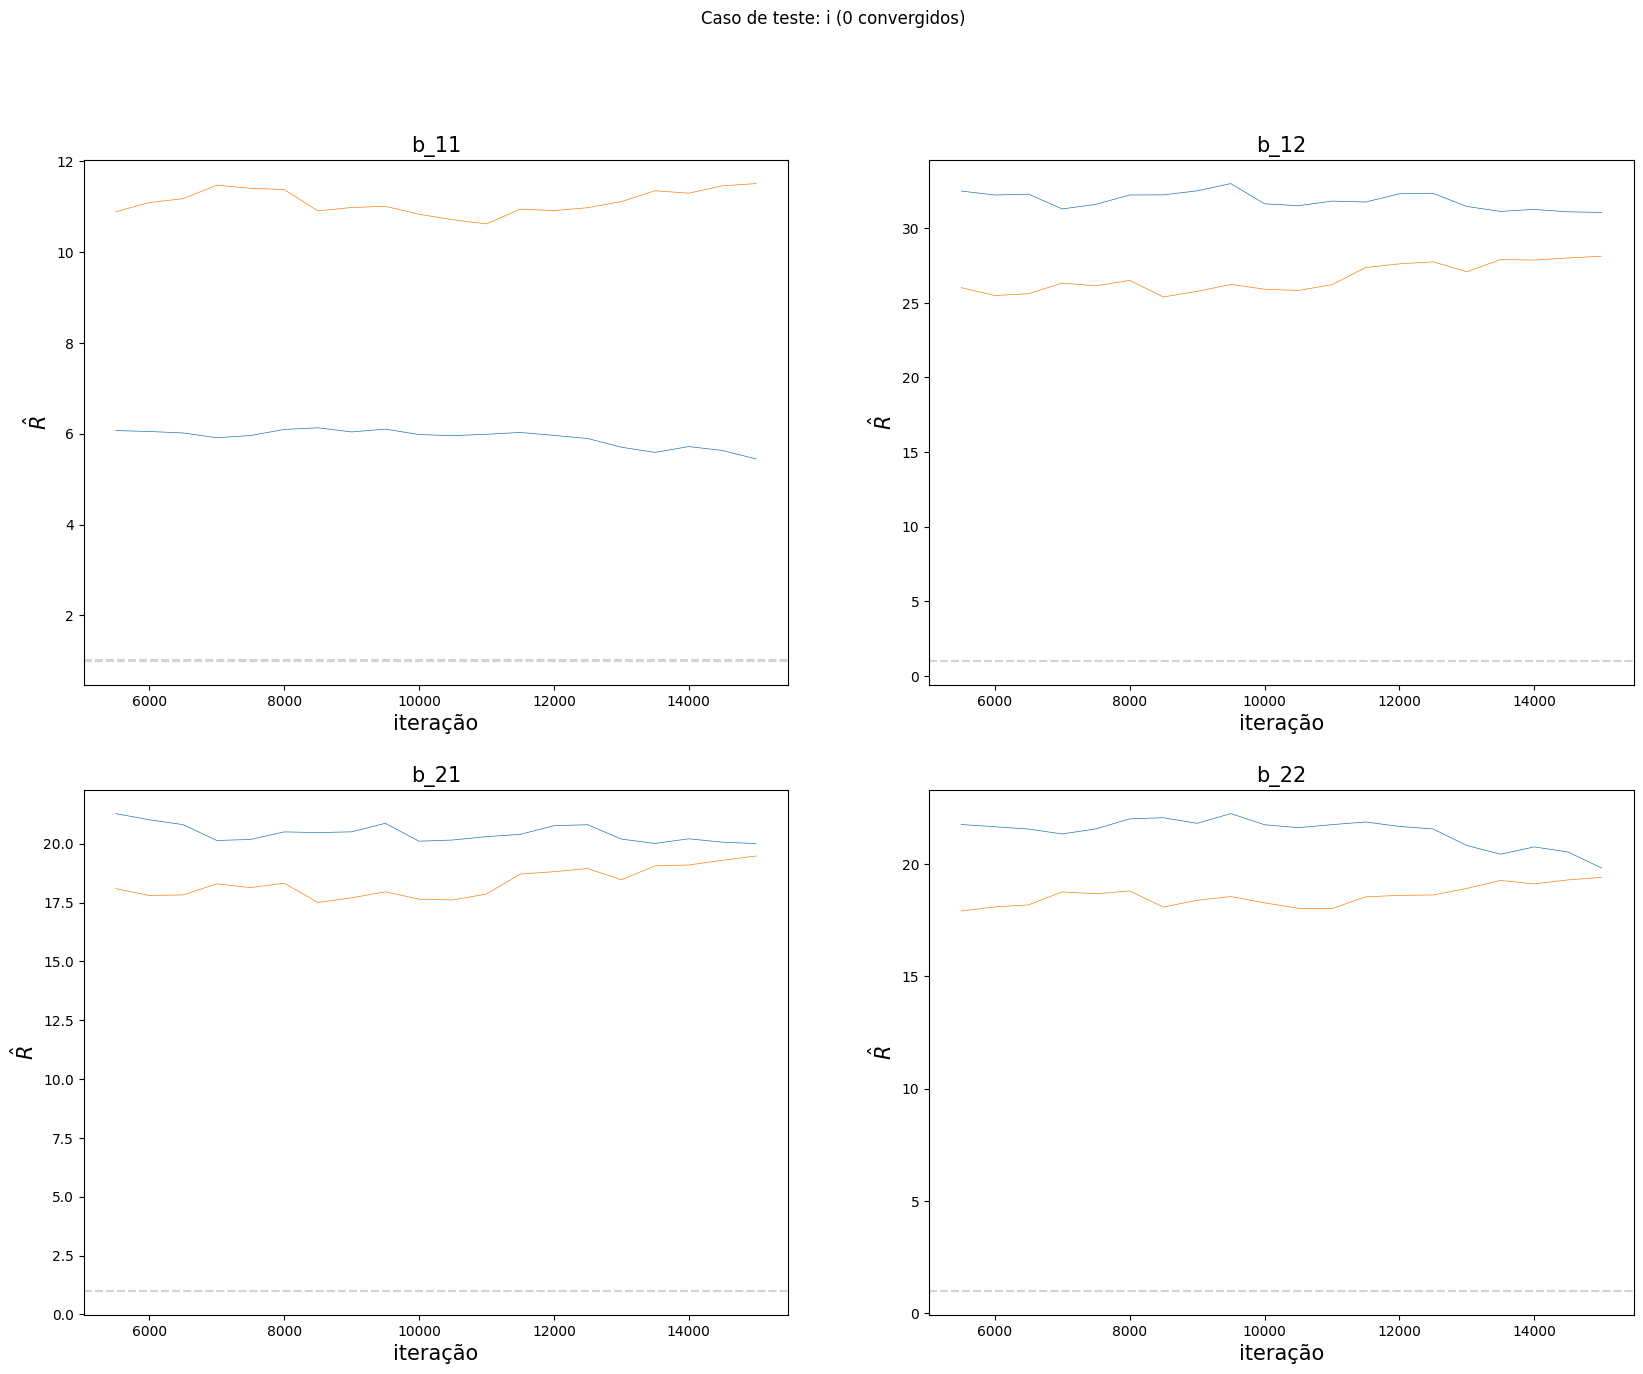

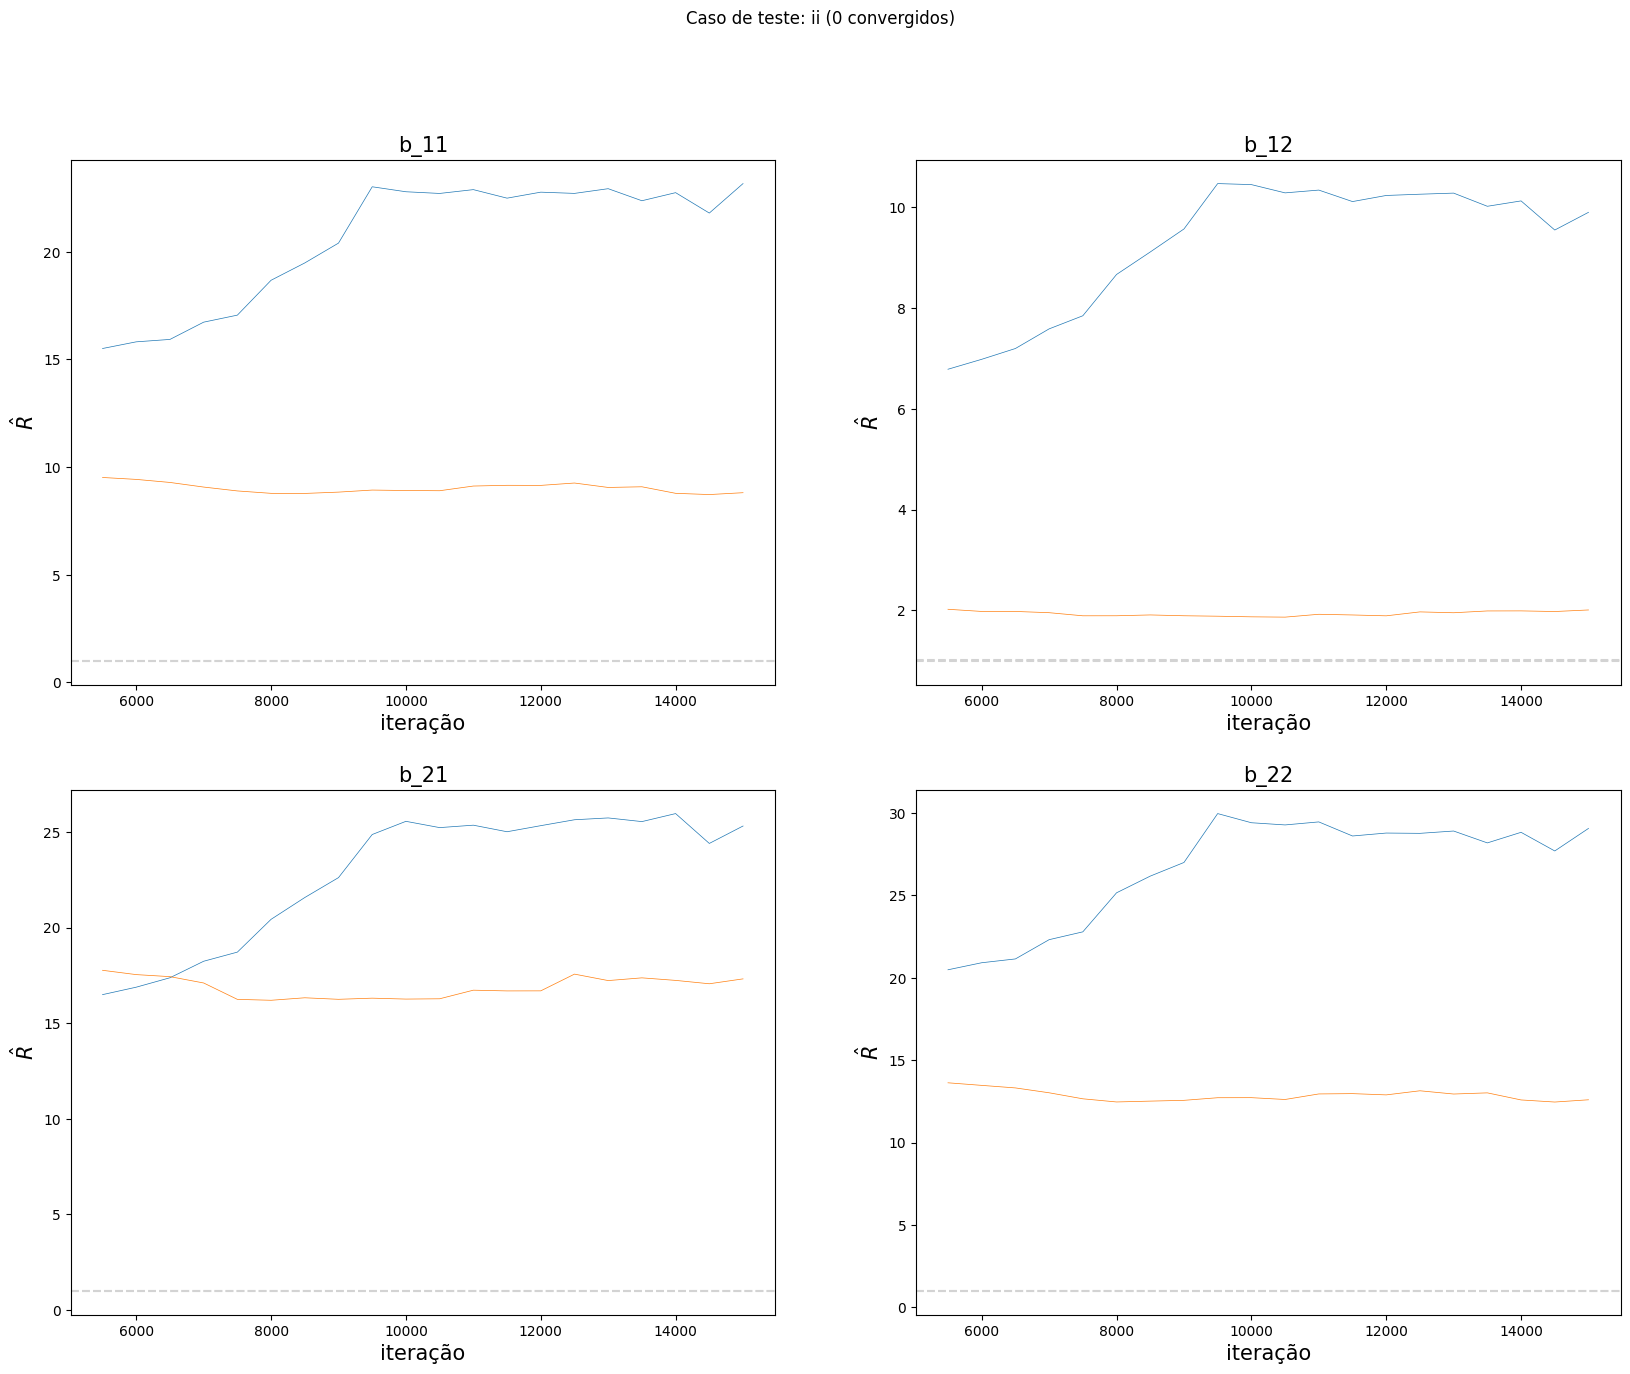

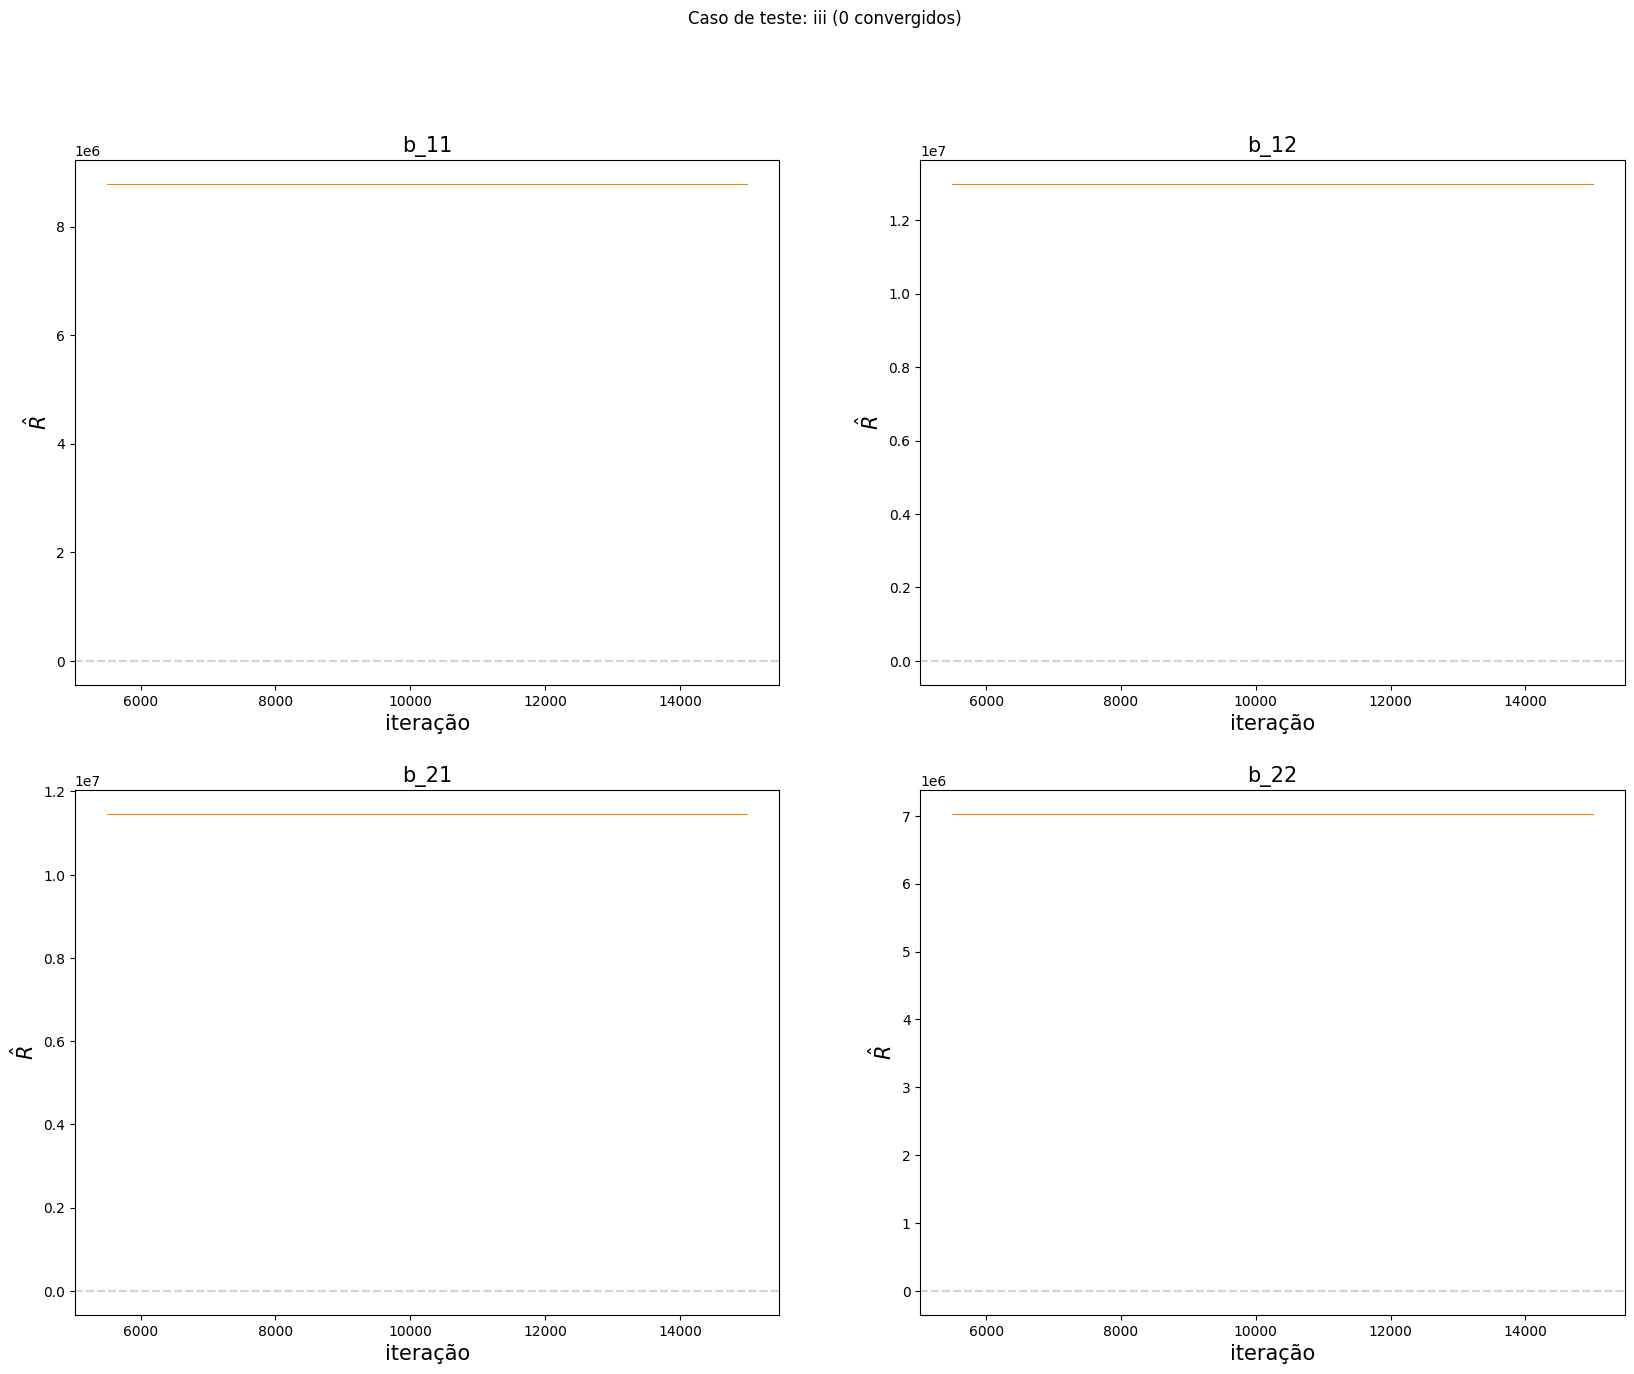

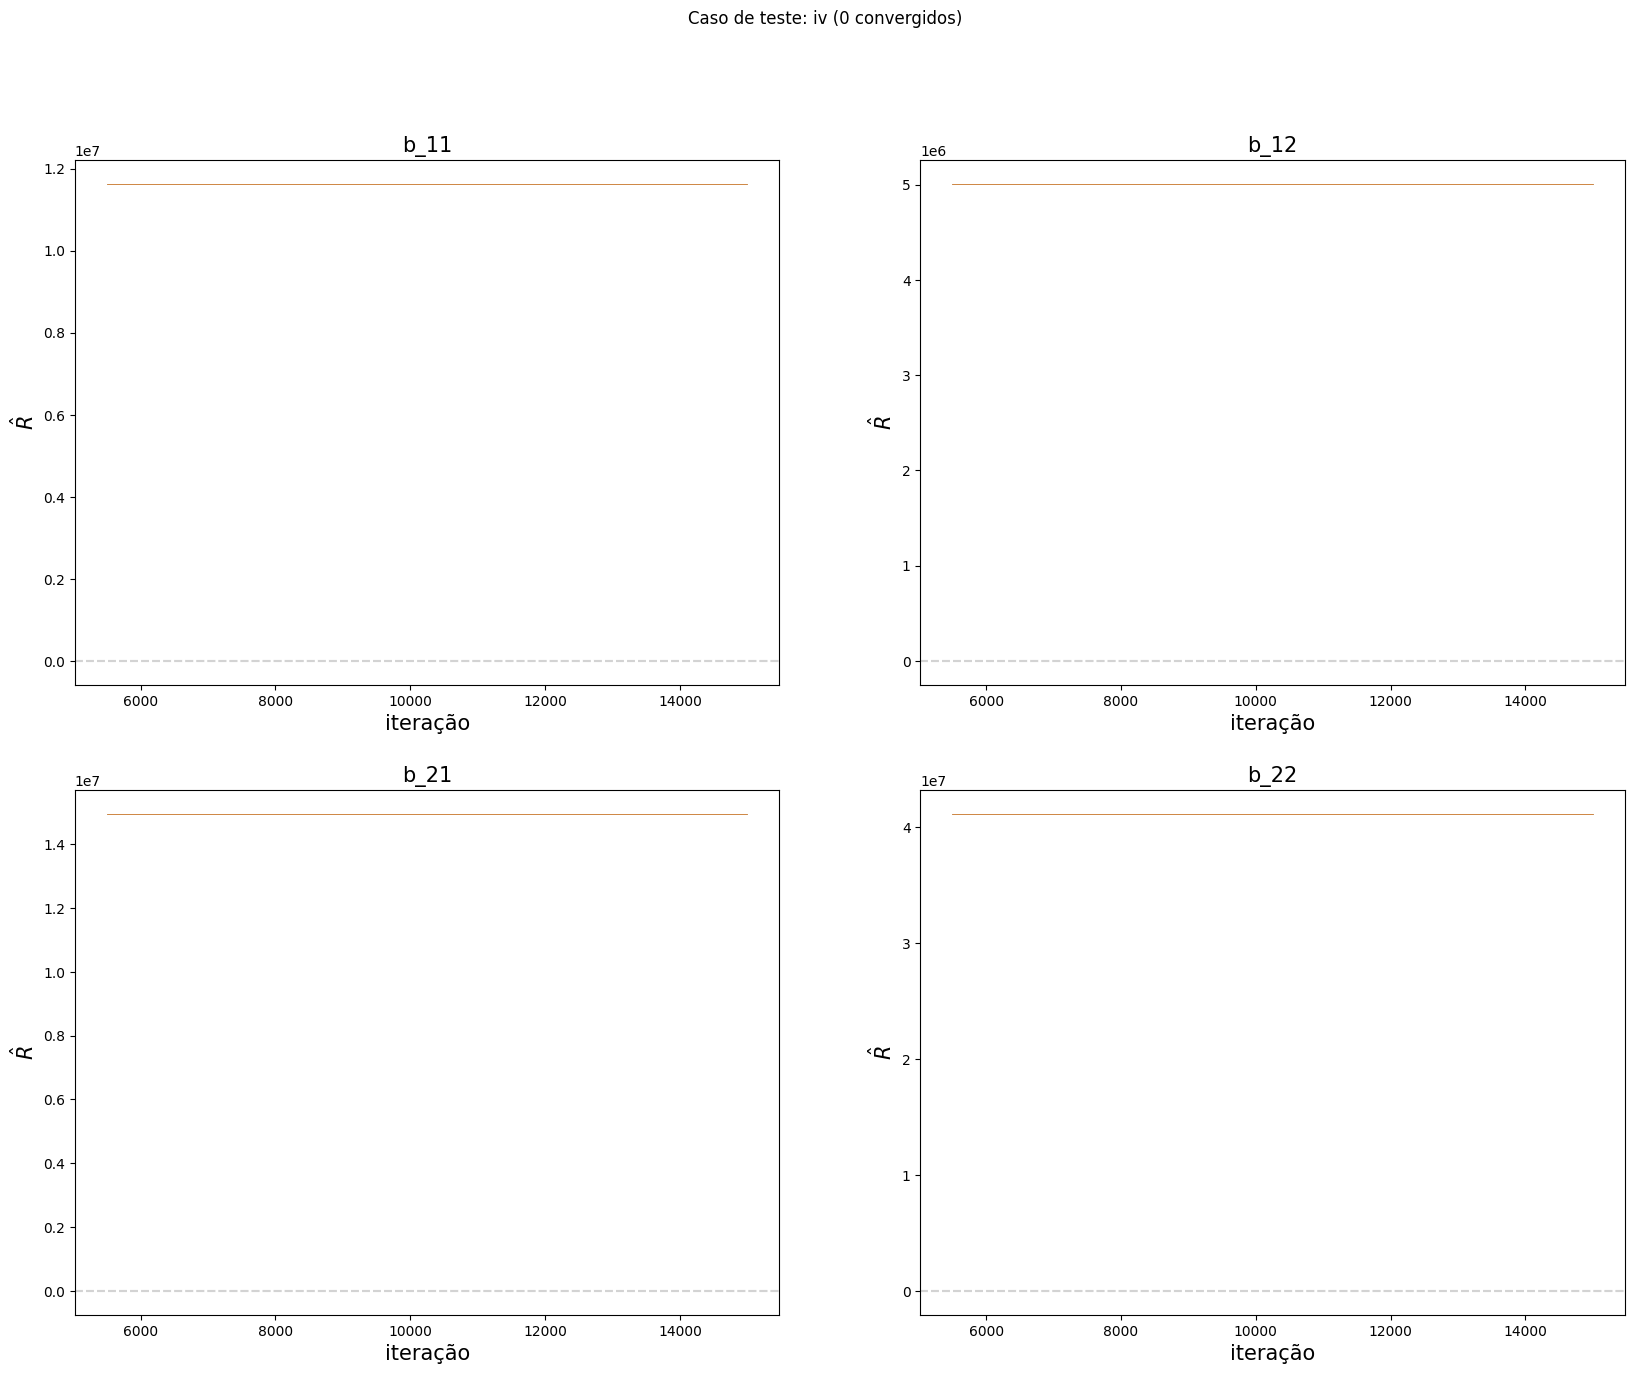

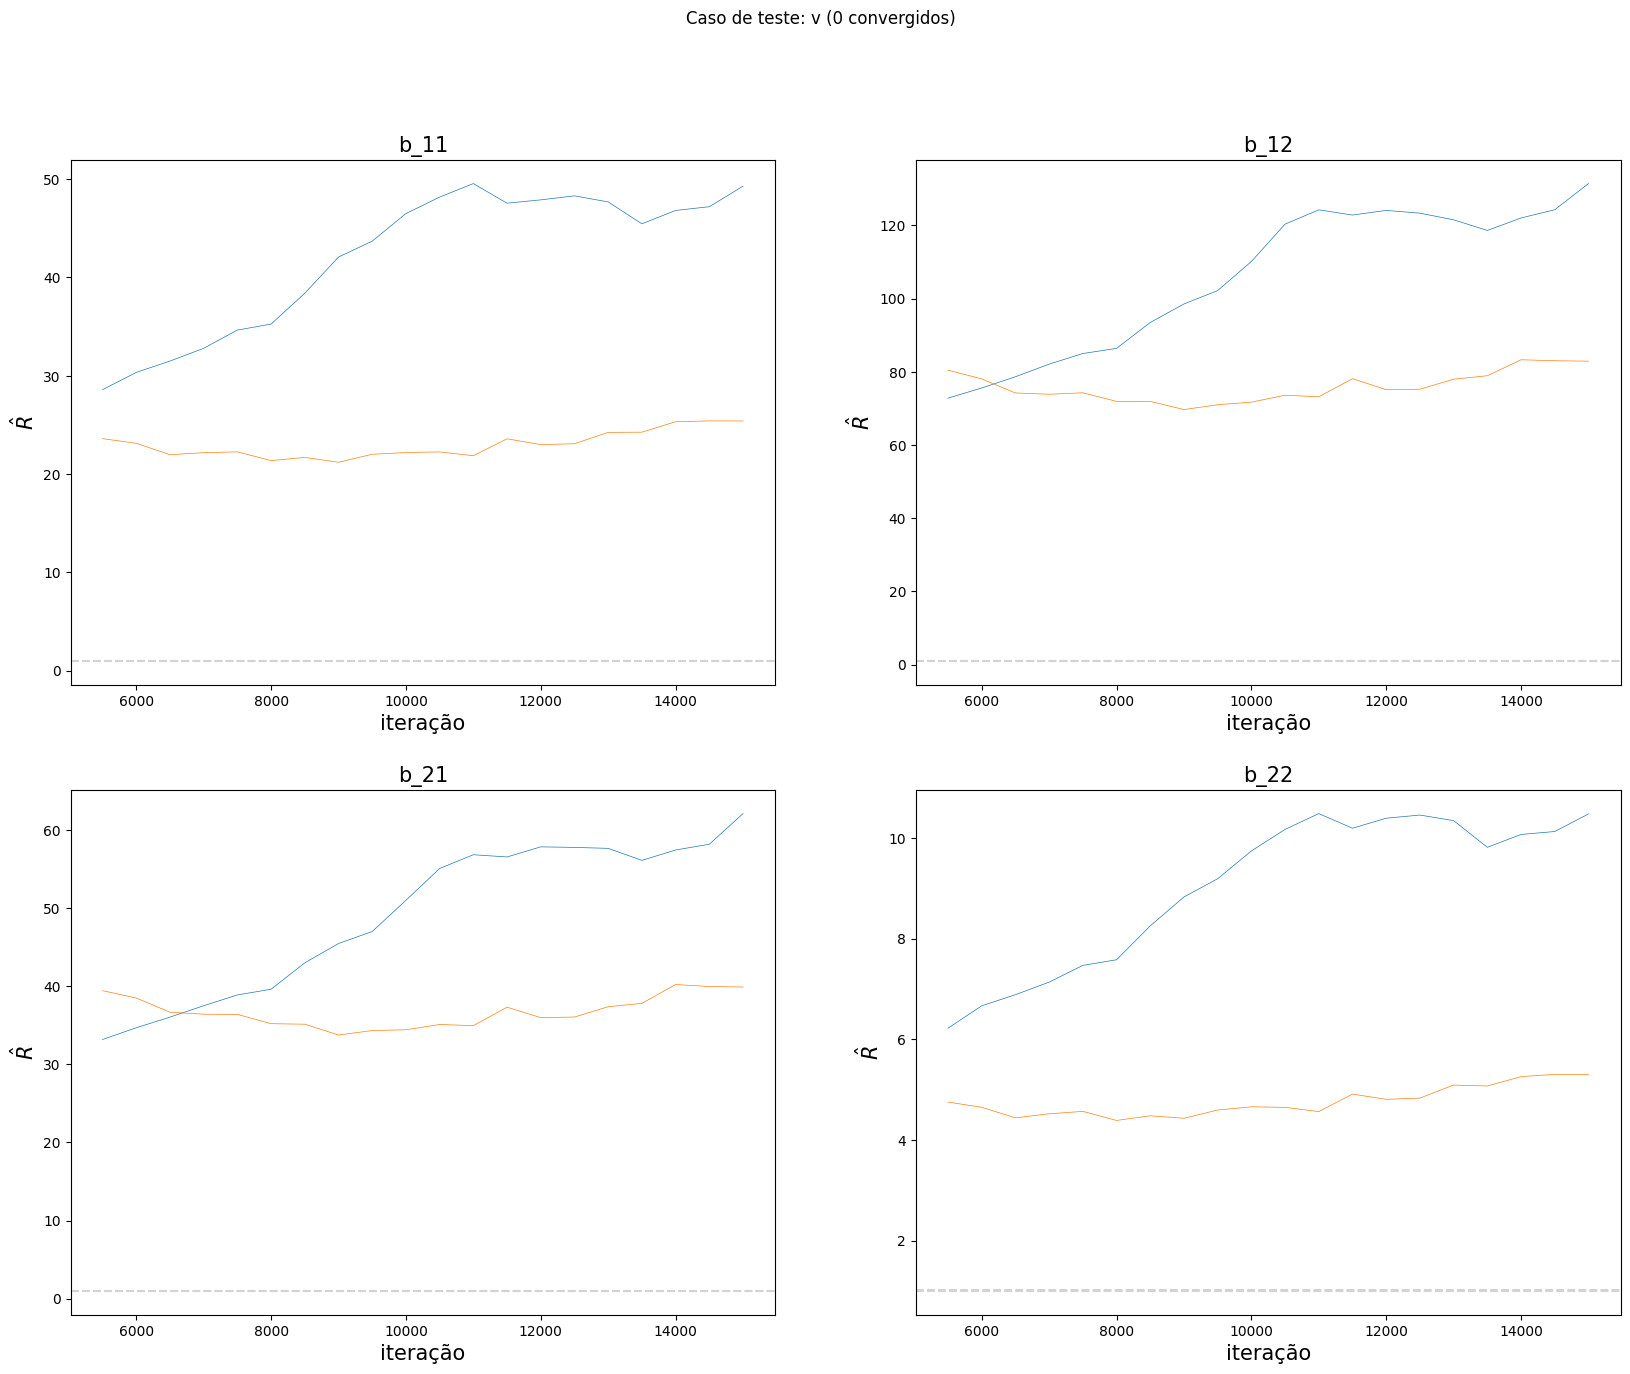

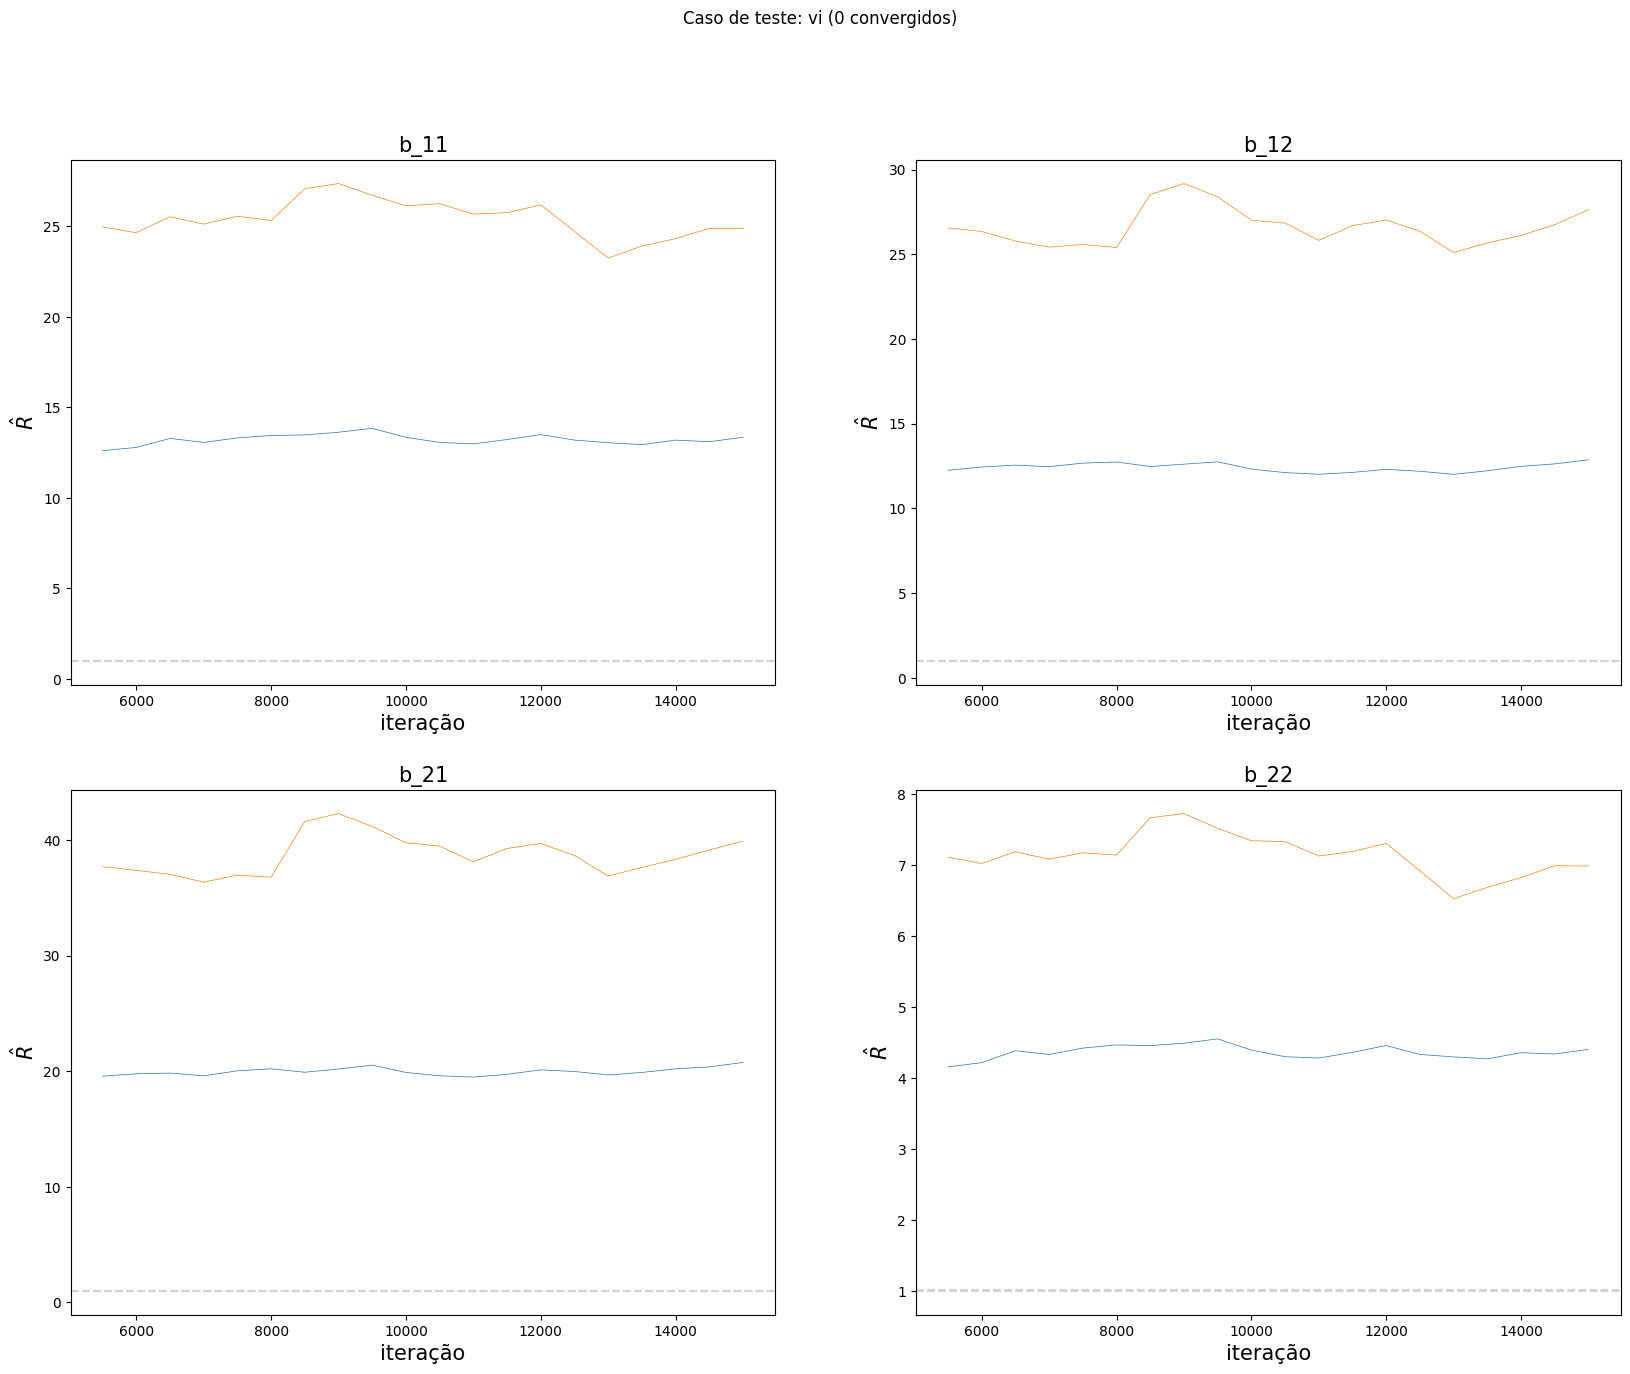

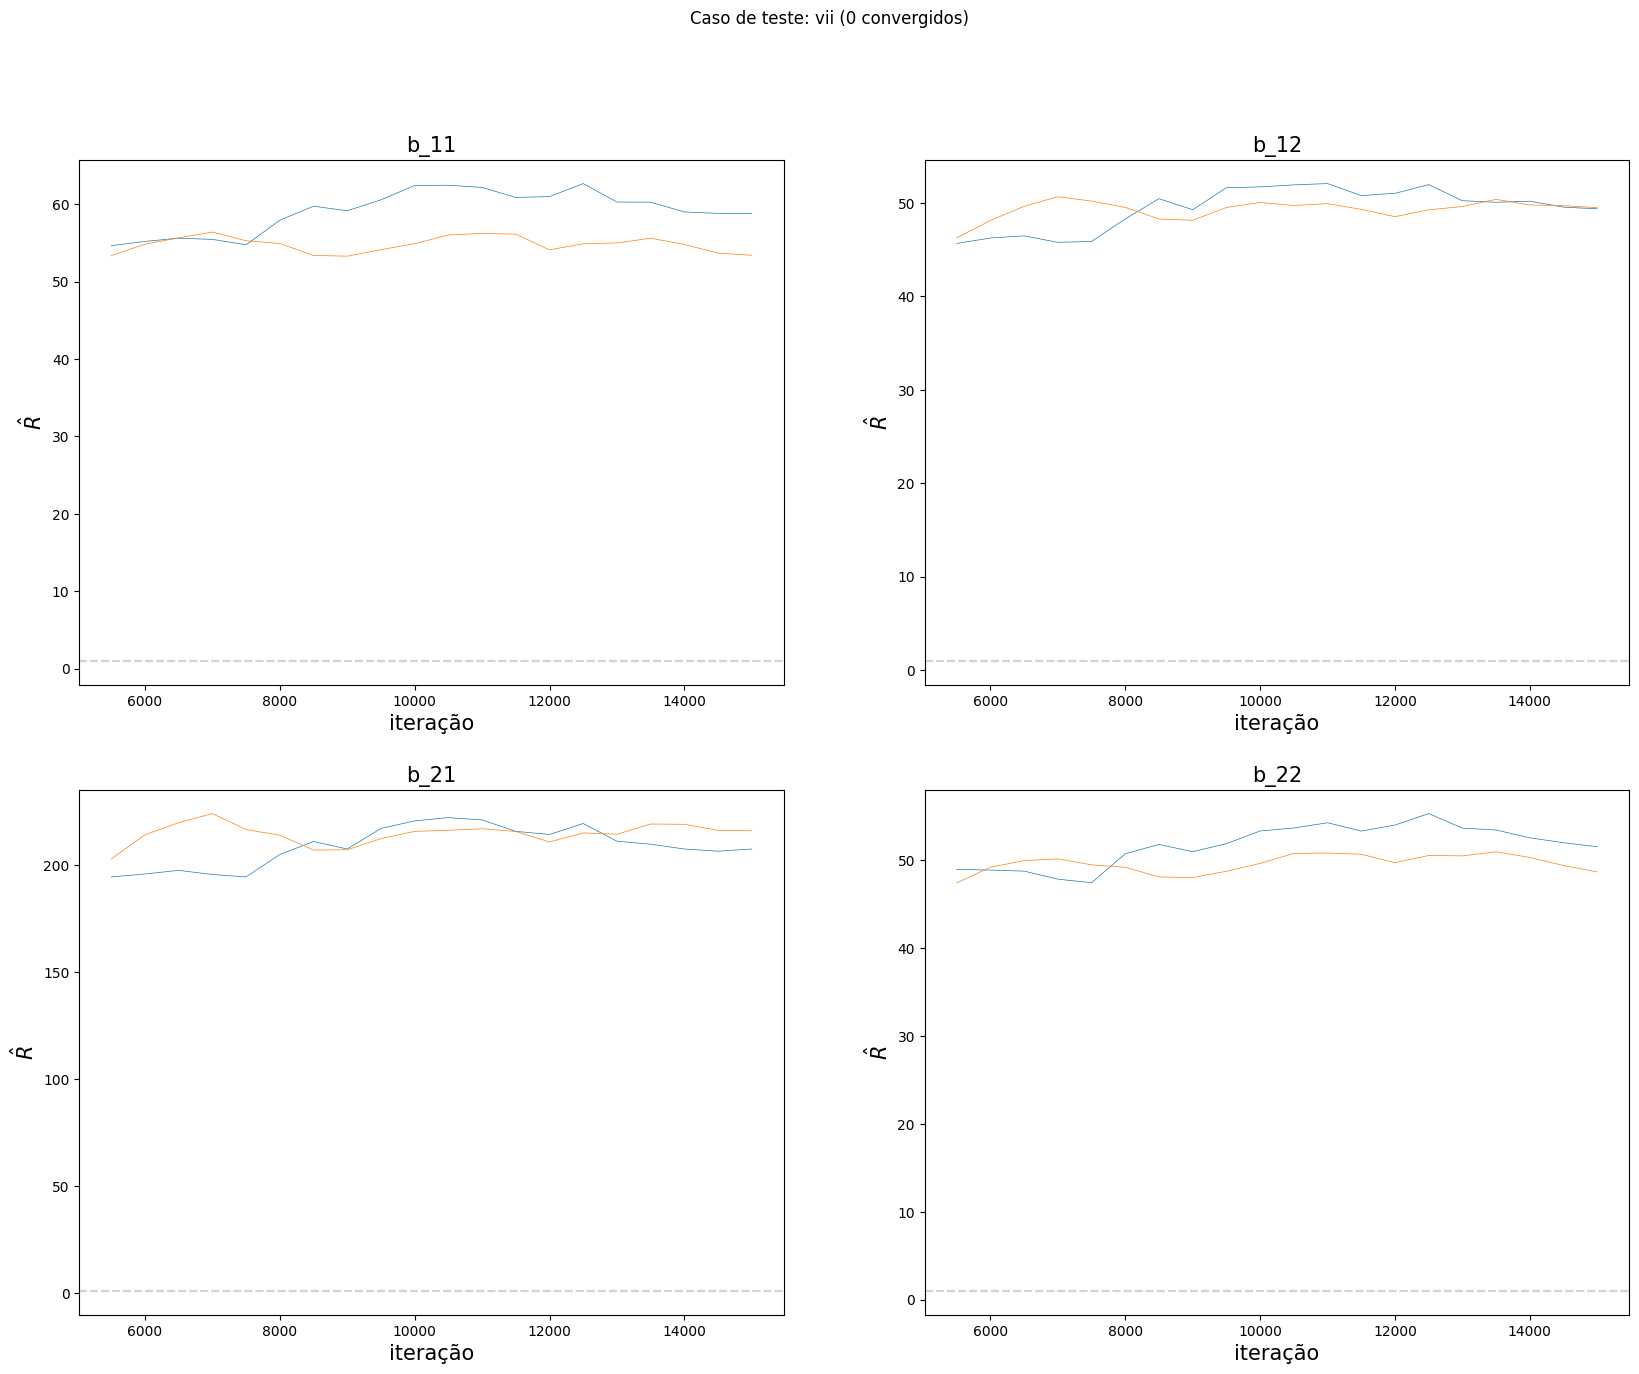

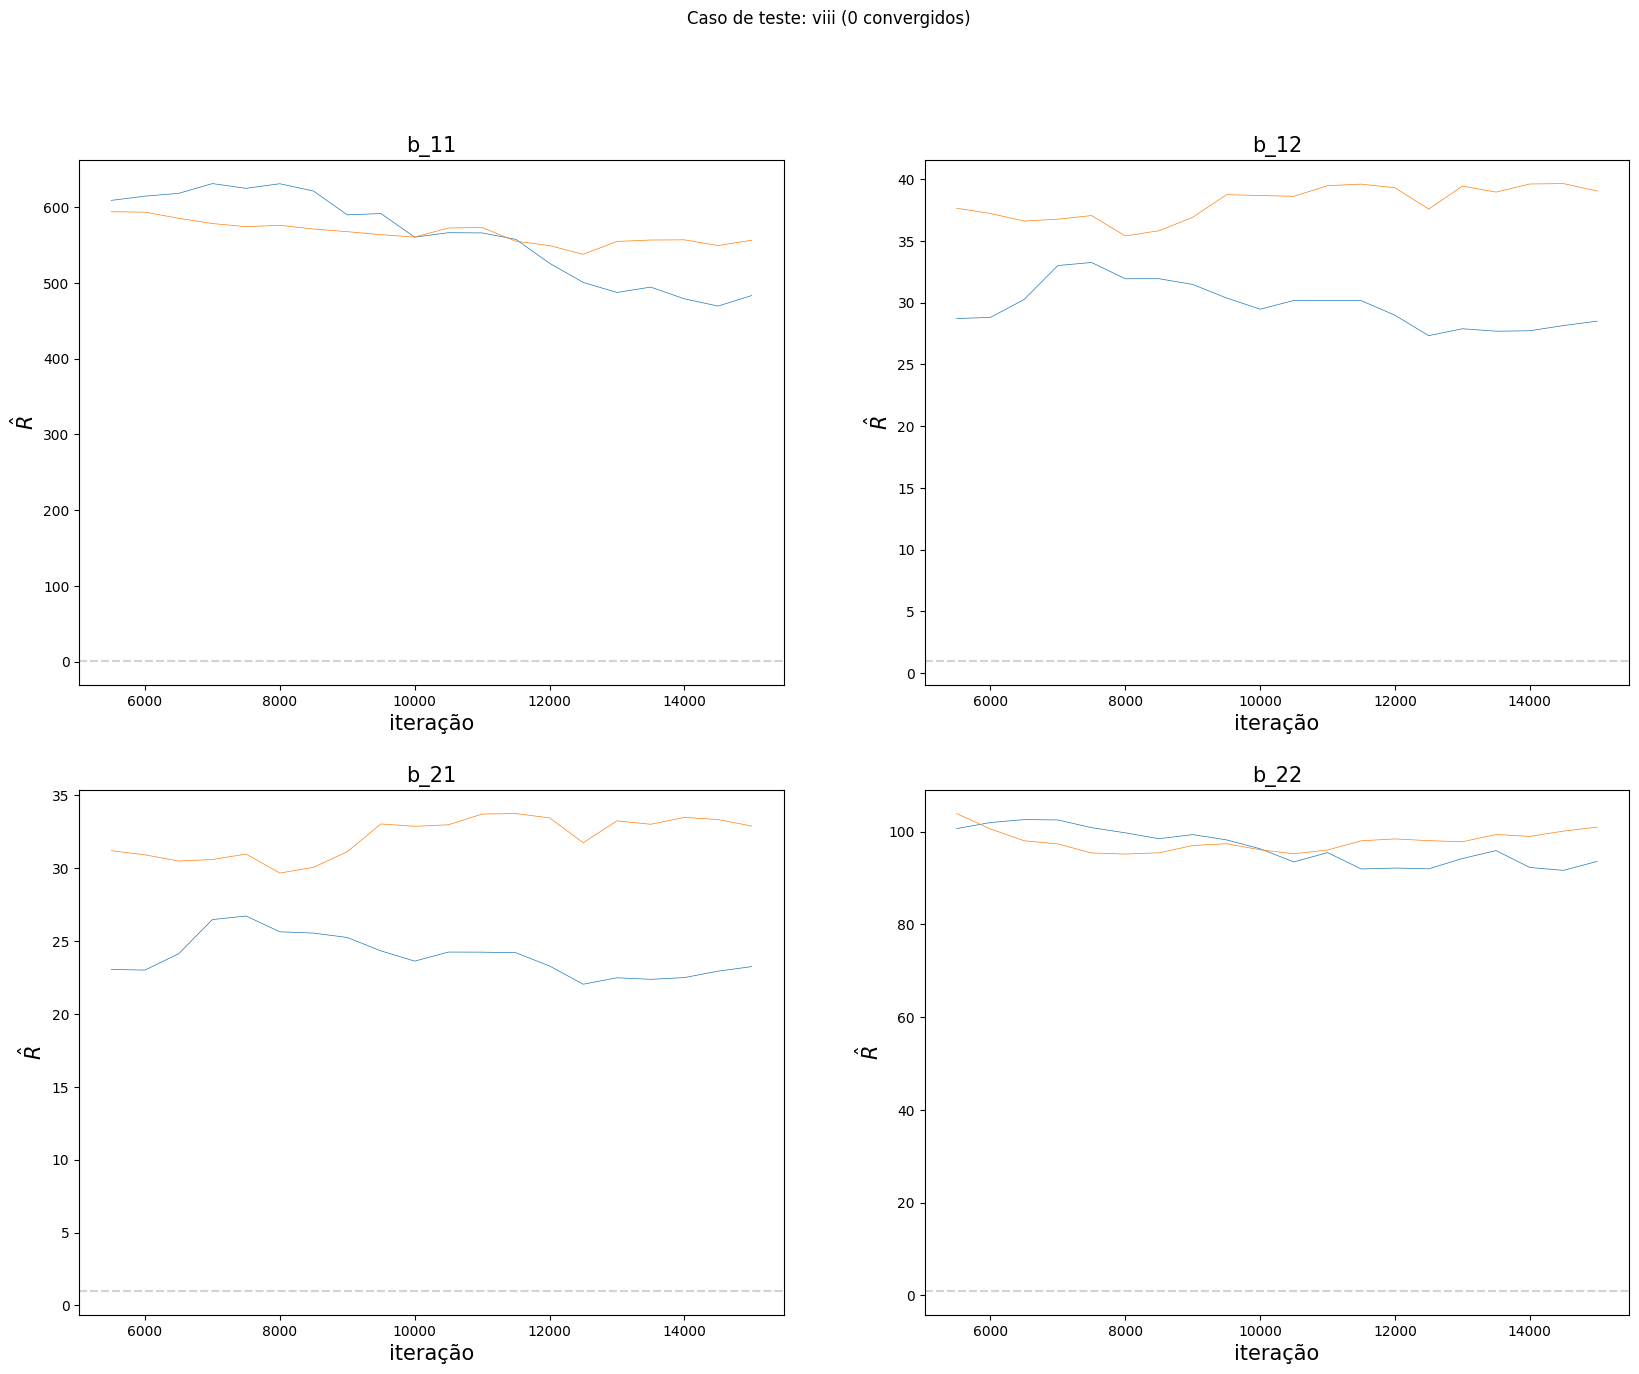

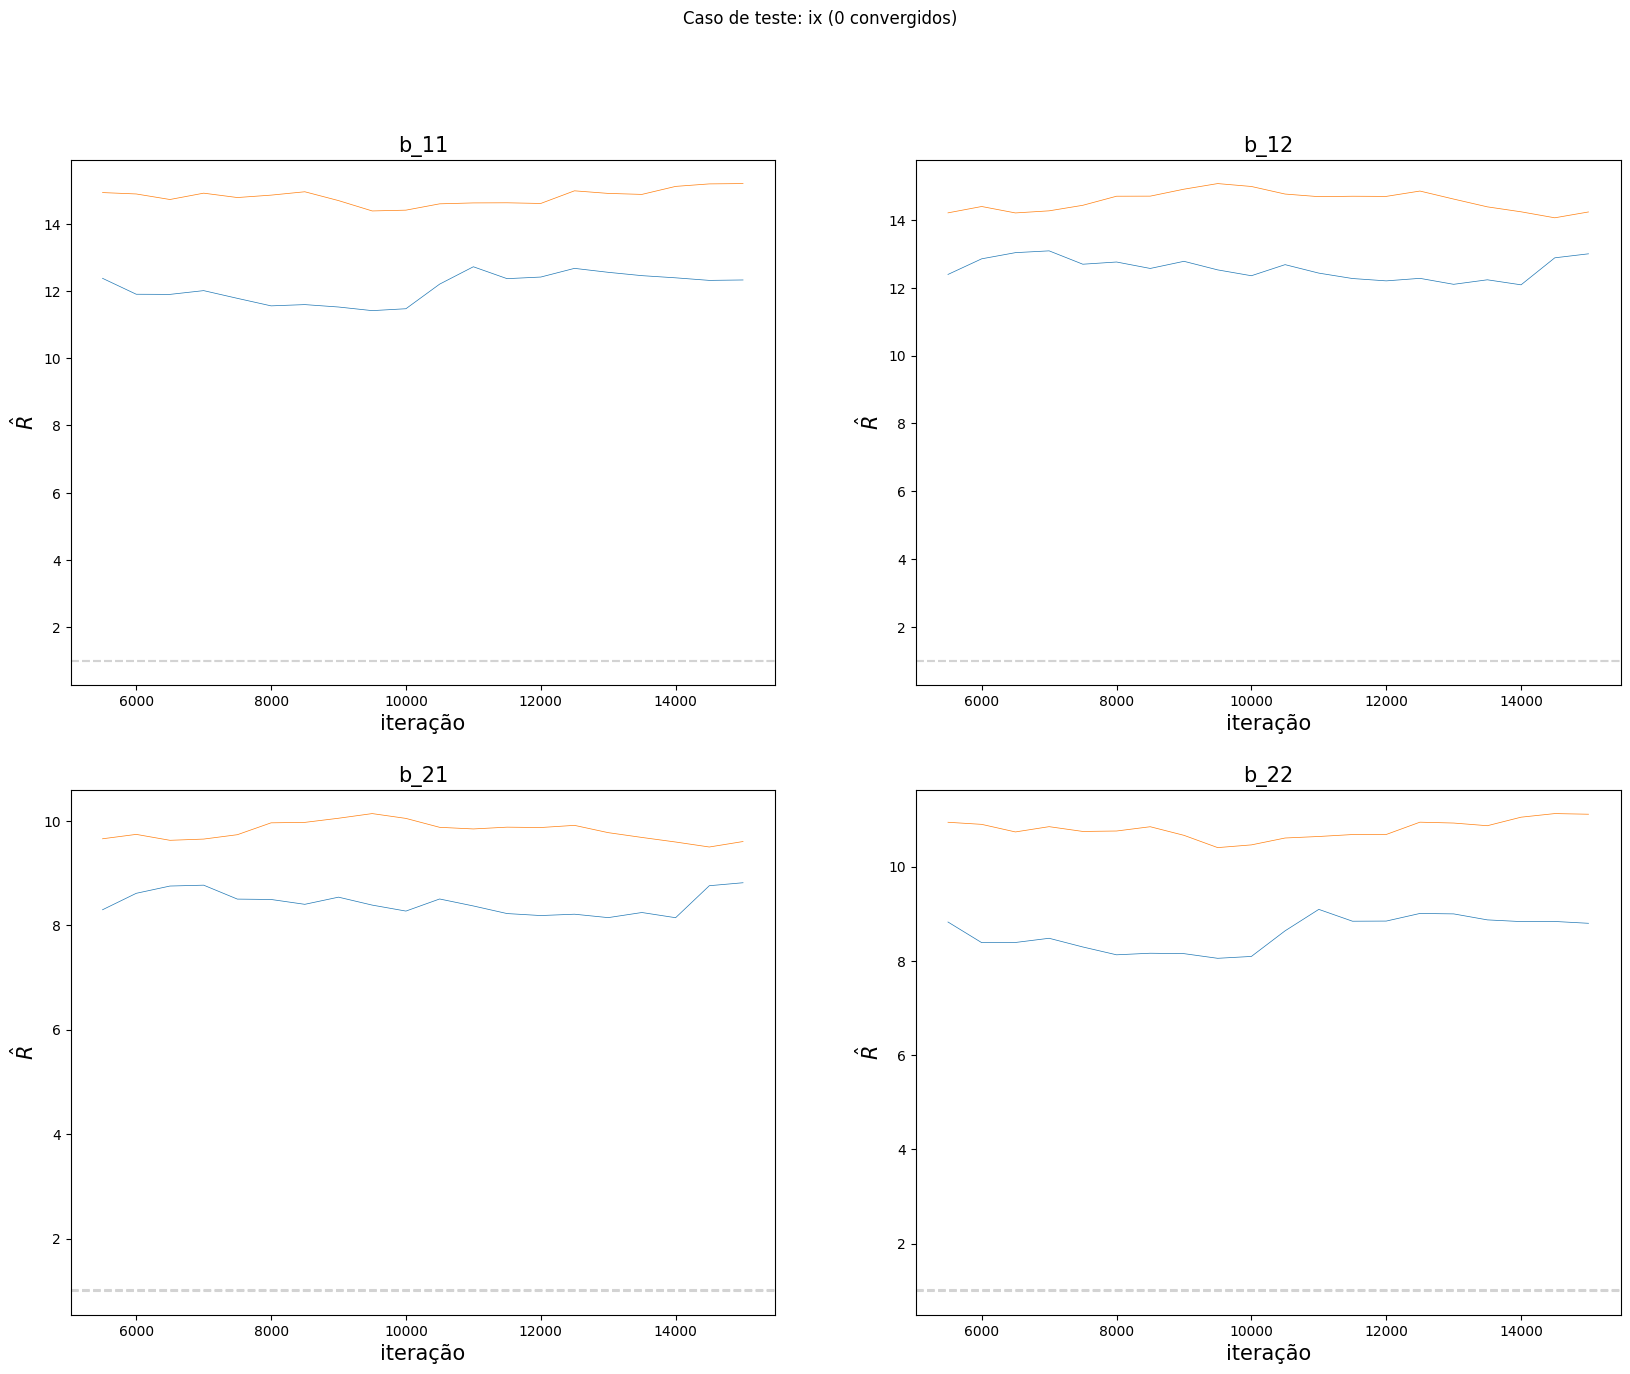

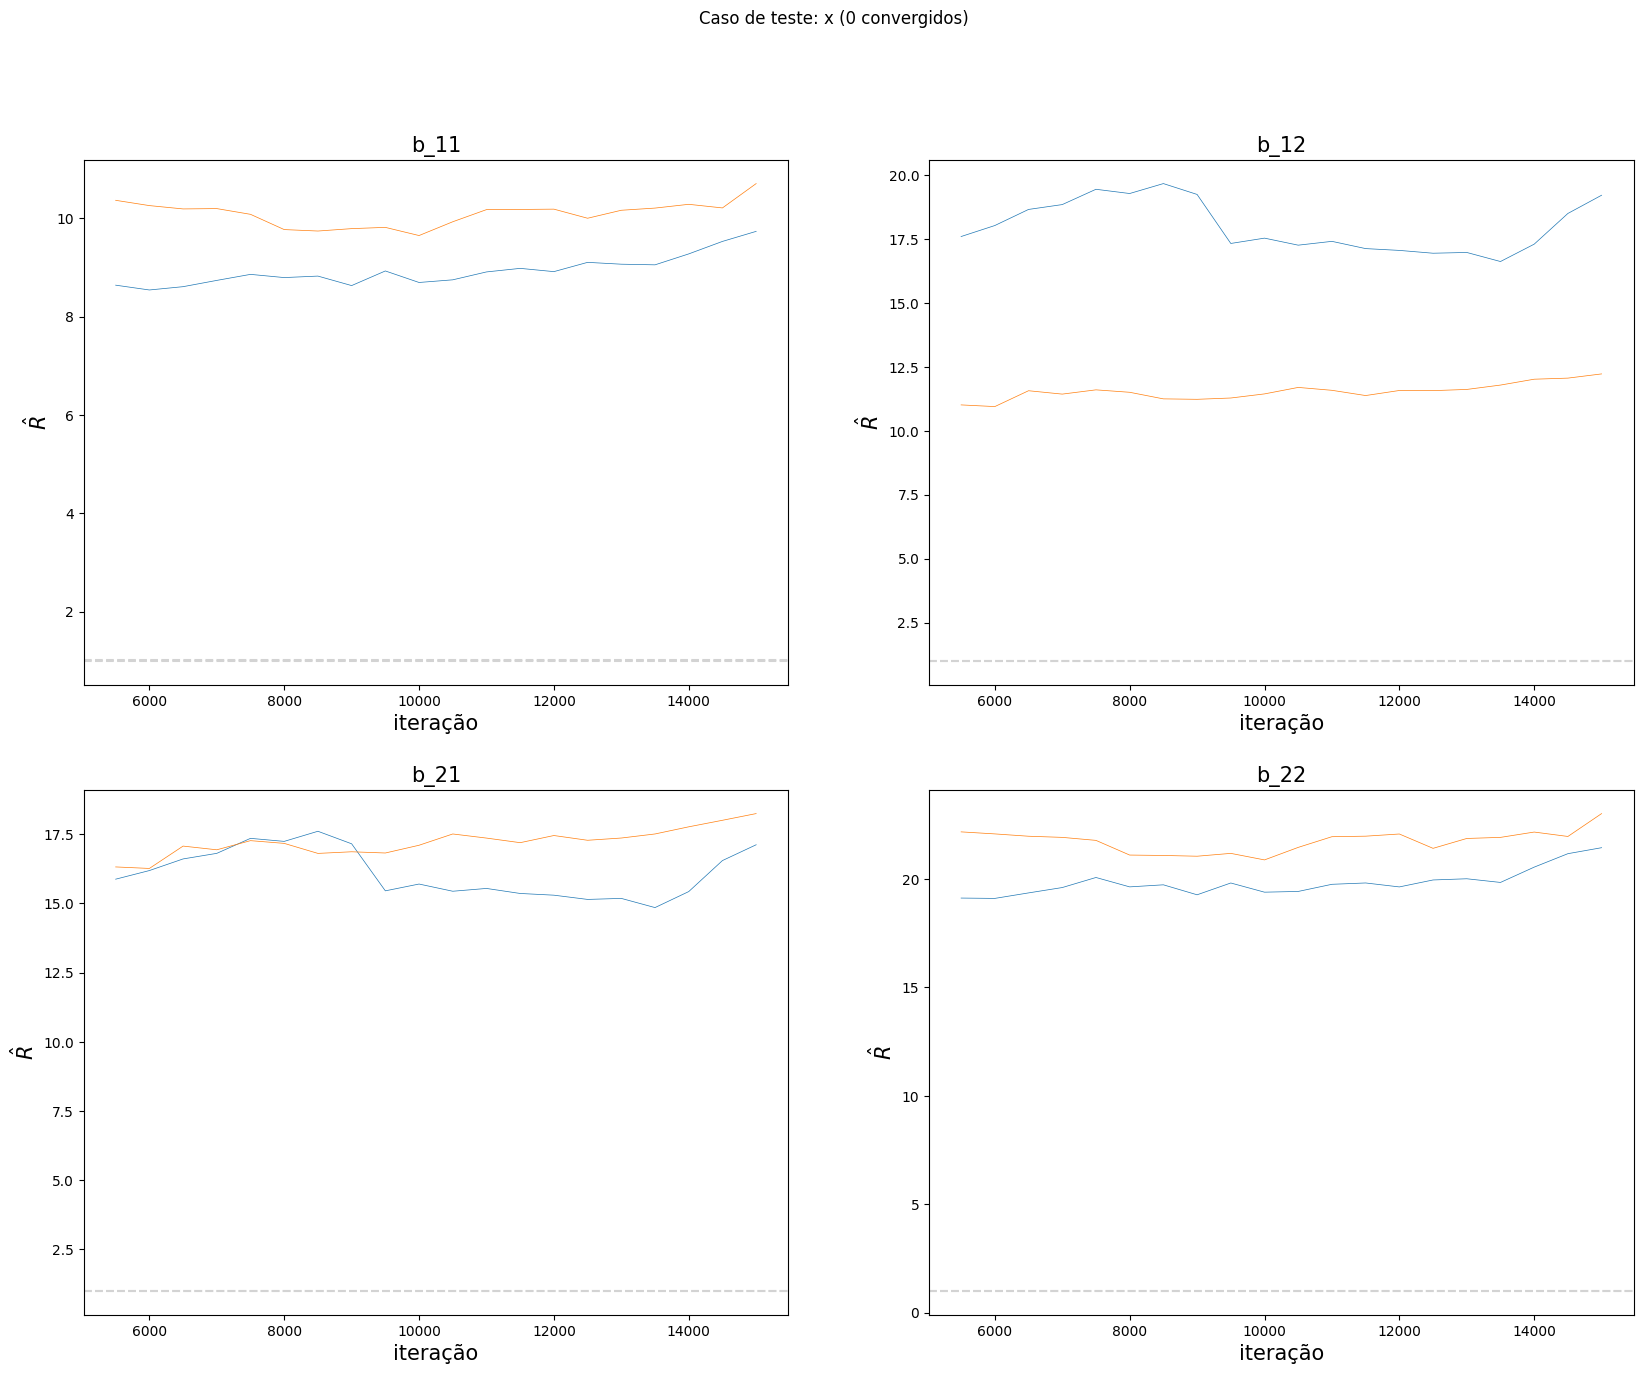

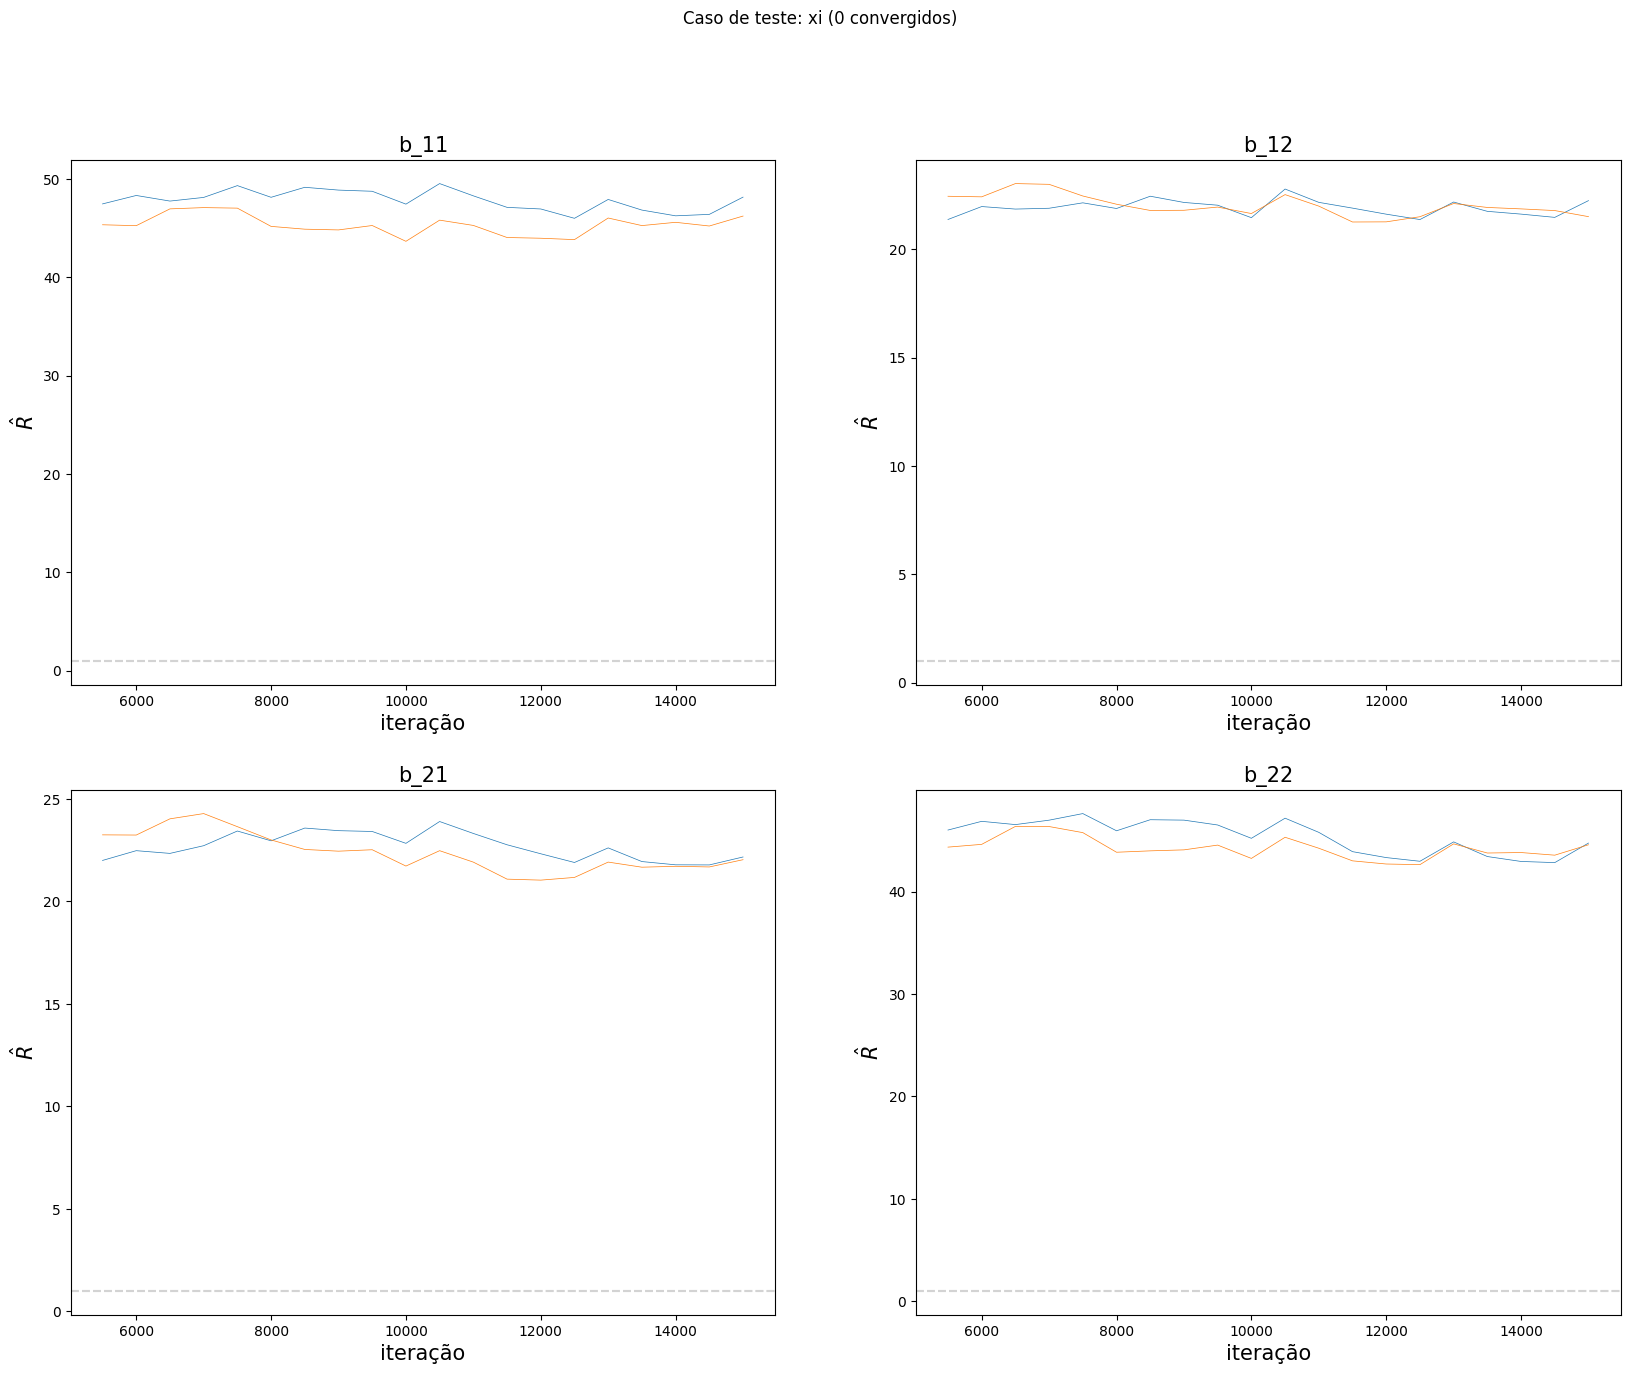

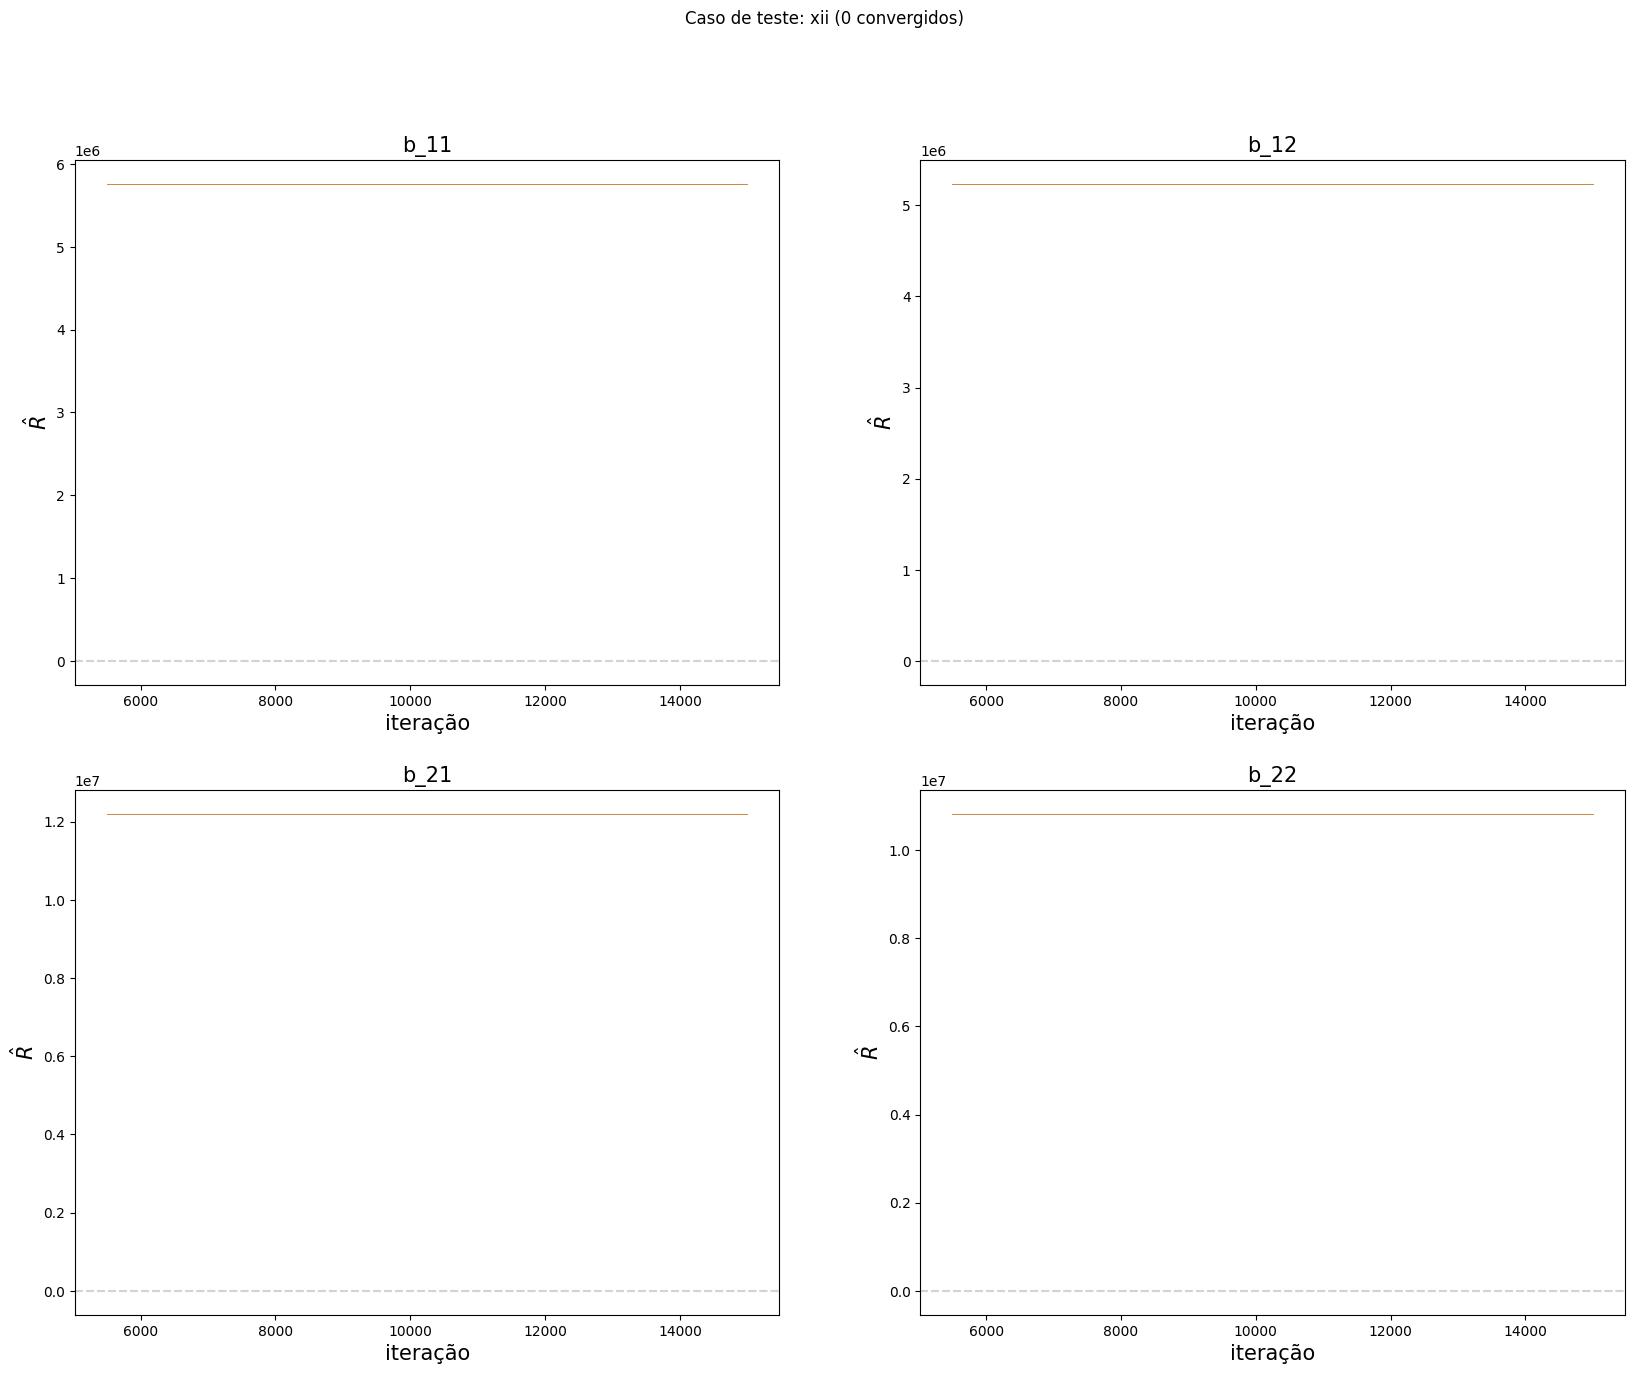

In [ ]:
for test_case, realizations_results in parser.parsed_results.items():
    fig, axs = plt.subplots(
        nrows=2, ncols=2,
        figsize=(20,15)
    )
    converged = np.sum(
        realizations_results['mmse']['converged']
    )
    fig.suptitle(
        'Caso de teste: {} ({} convergidos)'.format(test_case, converged)
    )

    for i, j in np.ndindex(parser.execution_config['general']['B'].shape):
        axs[i,j].axhline(
            1,
            color='lightgray',
            linestyle='--'
        )
        axs[i,j].axhline(
            parser.execution_config['mcmc']['R_hat_thresh'],
            color='lightgray',
            linestyle='--'
        )
        axs[i,j].set_xlabel(
            'iteração',
            fontsize=15
        )
        axs[i,j].set_ylabel(
            '$\hat{R}$',
            fontsize=15
        )
        axs[i,j].set_title(
            'b_{}'.format(str(i+1) + str(j+1)),
            fontsize=15
        )
        # print(realizations_results['mmse'].keys())
        for r, R_hats in zip(realizations_results['realization'], realizations_results['mmse']['diagnostics']):
            axs[i,j].plot(
                R_hats['iteration'],
                R_hats['r_hat_b_{}{}'.format(i+1, j+1)],
                # color='blue',
                linewidth=.5,
                # label=r
            )

        # l=axs[i,j].legend()

In [ ]:
def test_case_samples(
    case,
    realization,
    executor
):
    
    R_idx = np.where(
        np.array(parser.parsed_results[case]['realization'])==realization
    )[0][0]
    converged = parser.parsed_results[case]['mmse']['object'][R_idx].converged
    # estimated_mode = executor.cfg['sim']['test_cases'][case]['estimated_mode']
    R_hats = parser.parsed_results[case]['mmse']['object'][R_idx].diagnostics
    samples = parser.parsed_results[case]['mmse']['object'][R_idx].samples

    fig, axs = plt.subplots(
        nrows=2, ncols=2,
        figsize=(20,15)
    )

    for i, j in np.ndindex(B.shape):
        for c, s in enumerate(samples):
            axs[i,j].hist(
                s[:,i,j],
                alpha=0.3,
                bins='fd',
                label=c
            )
        
        axs[i,j].legend()

    
    print('R-hat convergiu? {}'.format(converged))
    # print('Ponto de partida:\n{}'.format(estimated_mode))
    
    return R_hats

R-hat convergiu? False


,iteration,r_hat_b_11,ess_b_11,r_hat_b_12,ess_b_12,r_hat_b_21,ess_b_21,r_hat_b_22,ess_b_22
0,5500,12.376677,2.014627,12.394972,2.014461,8.296010,2.032445,8.824366,2.028530
1,6000,11.903041,2.015695,12.855842,2.013336,8.610998,2.029769,8.386290,2.031494
2,6500,11.898880,2.015606,13.037410,2.013195,8.750112,2.029384,8.389899,2.031544
3,7000,12.010700,2.015422,13.090447,2.013285,8.766874,2.029577,8.479215,2.030990
4,7500,11.781074,2.016080,12.696436,2.014156,8.500195,2.031552,8.294703,2.032555
5,8000,11.557578,2.016814,12.761657,2.014156,8.492964,2.031943,8.128569,2.034207
6,8500,11.594981,2.016753,12.571569,2.014270,8.400175,2.031931,8.161924,2.033736
7,9000,11.523490,2.016656,12.782067,2.013597,8.537333,2.030309,8.153109,2.033221
8,9500,11.415668,2.017034,12.529353,2.014184,8.385160,2.031454,8.054309,2.034183
9,10000,11.472125,2.017134,12.356817,2.014845,8.270825,2.033502,8.093817,2.034492


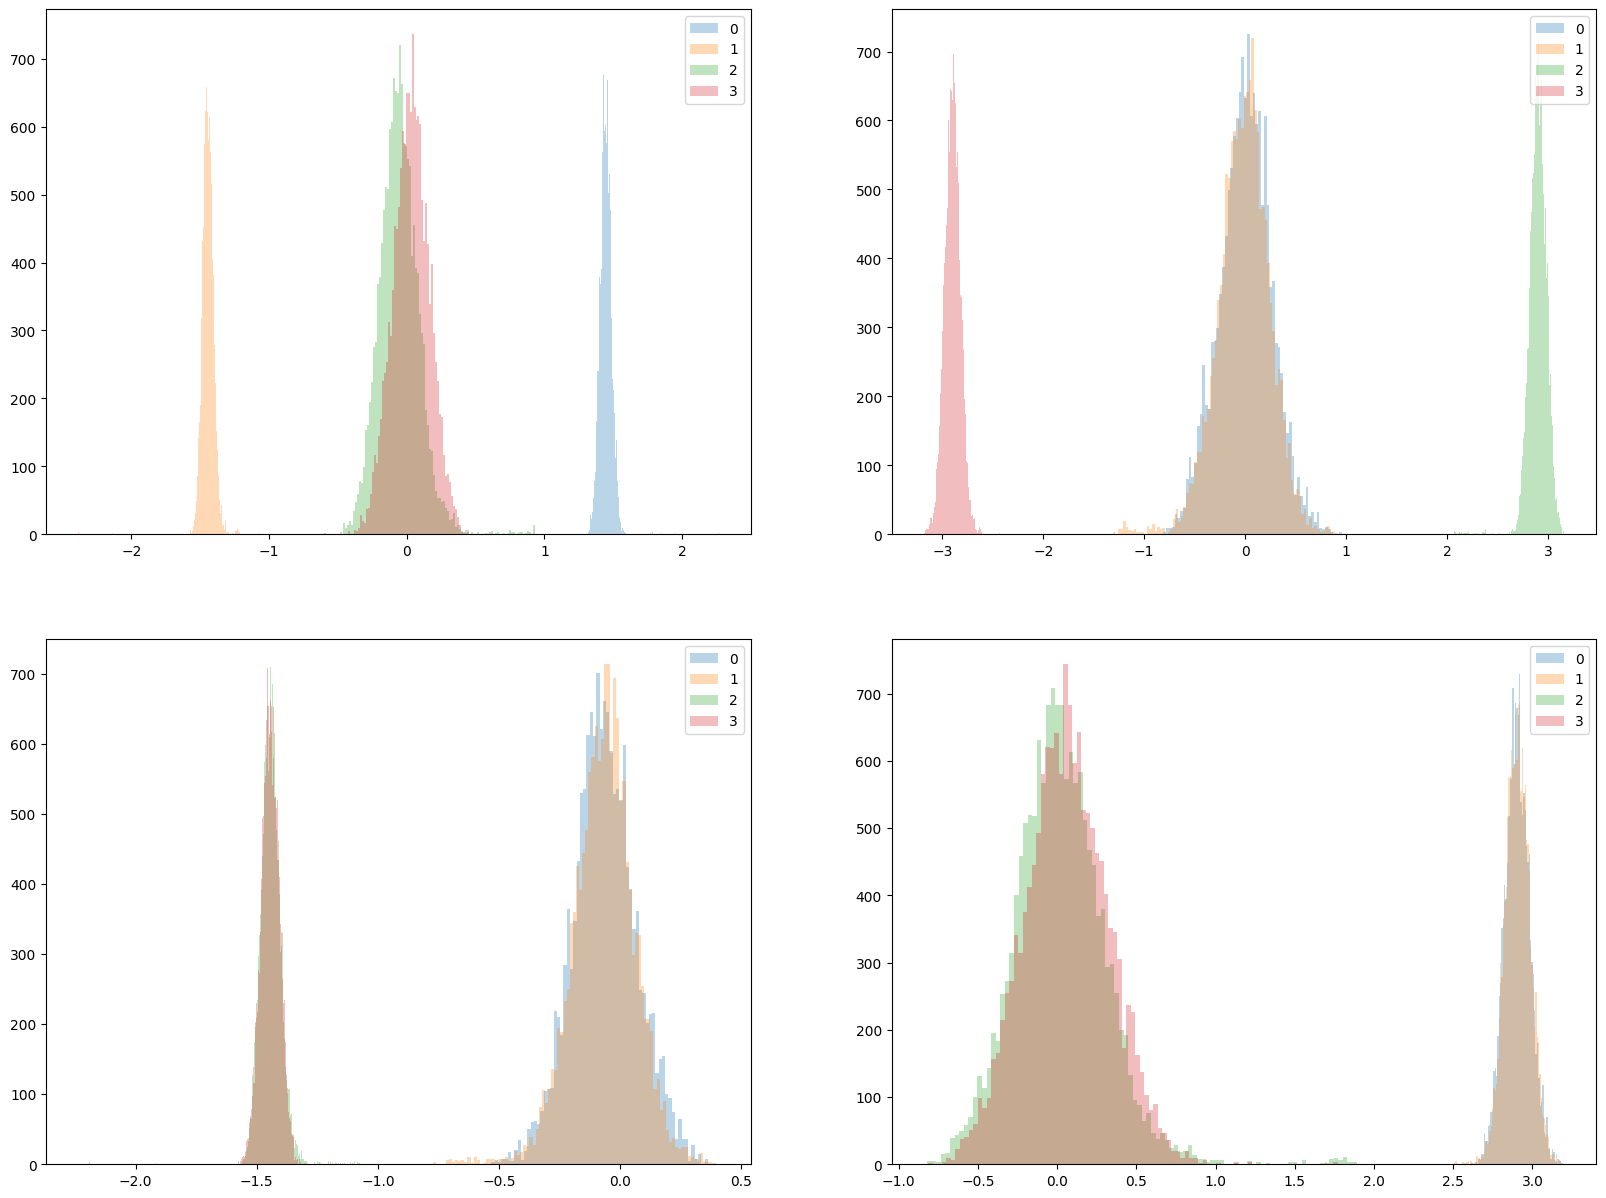

In [ ]:
CASE = 'ix'
REALIZATION = '0'
test_case_samples(
    case=CASE,
    realization=REALIZATION,
    executor=ex
)

In [ ]:
CASE = 'i'
REALIZATION = '3'
test_case_samples(
    case=CASE,
    realization=REALIZATION,
    executor=ex
)

IndexError: index 0 is out of bounds for axis 0 with size 0

In [ ]:
ex.cfg['sim']['test_cases'][CASO]['estimated_mode']

array([[ 1.032024  , -1.97850433],
       [ 1.00554089,  1.97295774]])

In [ ]:
ex.initial_mode_seeking_results['estimated_modes']

{'i': array([[ 0.49999882, -1.00152771],
        [ 0.49063647,  1.00000907]]),
 'ii': array([[ 0.49999882, -1.00152768],
        [ 0.4906366 ,  1.00000907]]),
 'iii': array([[ 0.49999882, -1.00148753],
        [ 0.49085312,  1.00000907]]),
 'iv': array([[ 0.5032277 , -0.99165864],
        [ 0.48798804,  1.00319585]]),
 'v': array([[ 0.45739613, -0.93379453],
        [ 0.44693805,  0.93220387]]),
 'vi': array([[ 0.45739714, -0.93379857],
        [ 0.4469392 ,  0.93220787]]),
 'vii': array([[ 0.45795966, -0.93797519],
        [ 0.44777134,  0.93625604]]),
 'viii': array([[ 0.46462762, -0.8962222 ],
        [ 0.43323033,  0.92661815]]),
 'ix': array([[ 1.032024  , -1.97850433],
        [ 1.00554089,  1.97295774]]),
 'x': array([[ 1.03194603, -1.97825141],
        [ 1.005466  ,  1.97269478]]),
 'xi': array([[ 0.99554765, -1.71612359],
        [ 0.97765782,  1.71207168]]),
 'xii': array([[ 0.99068498, -1.58355662],
        [ 0.94448086,  1.62113481]])}